# RMGA / ViTTA Experiment Visualization Suite

This notebook reads and parses all experiment logs in this folder (`*.txt`) and generates professional comparison plots for:

- Train-time best test accuracy
- ViTTA-enabled evaluation accuracy
- RMGA-enabled evaluation accuracy
- Running-accuracy trajectories during training, ViTTA inference, and RMGA inference
- Per-class accuracy analysis across all model/configuration runs

The parsing is file-driven (no manual spreadsheet copy), so plots stay consistent with your raw logs.

In [1]:
from __future__ import annotations

from pathlib import Path
import re
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

LOG_DIR = Path(".")
LOG_FILES = sorted(LOG_DIR.glob("*.txt"))
print(f"Detected {len(LOG_FILES)} log files")
for p in LOG_FILES:
    print(" -", p.name)


Detected 9 log files
 - 3Dresnet18(16 frames, 24 batch size, 1 epoch).txt
 - 3Dresnet18(32 frames, 40 batch size, 1 epoch).txt
 - 3Dresnet18(8 frames, 40 batch size, 1 epoch).txt
 - R2+1d_18, (16 frames, 24 batchsize, 2 epochs).txt
 - R2+1d_18, (8 frames, 40 batchsize, 2 epochs).txt
 - mc3_18(24 batchsize, 16 frames, 2 epochs).txt
 - mc3_18(32 frames, 40 batch_size, 2 epoch).txt
 - mc3_18(40 batchsize, 8 frames, 2 epochs).txt
 - r2plus1d_18, (32 frames, 40 batch_size, 2 epochs)).txt


In [2]:
MODEL_ORDER = ["r3d_18", "mc3_18", "r2plus1d_18"]
MODEL_LABELS = {
    "r3d_18": "3DResNet18 (r3d_18)",
    "mc3_18": "MC3-18",
    "r2plus1d_18": "R(2+1)D-18",
}


def normalize_model_name(raw: str) -> str:
    s = raw.lower().strip().replace("+", "plus")
    s = s.replace(" ", "").replace(",", "")
    if "r3d" in s or "3dresnet" in s:
        return "r3d_18"
    if "mc3" in s:
        return "mc3_18"
    if "r2plus1d" in s or "r2plus1d_18" in s:
        return "r2plus1d_18"
    return raw.strip()


def parse_filename_config(filename: str) -> dict:
    stem = Path(filename).stem

    frames_m = re.search(r"(\d+)\s*frames", stem, flags=re.IGNORECASE)
    batch_m = re.search(r"(\d+)\s*batch(?:[_\s]*size)?", stem, flags=re.IGNORECASE)
    epochs_m = re.search(r"(\d+)\s*epoch", stem, flags=re.IGNORECASE)

    model_token = stem.split("(")[0].strip().strip(",")

    return {
        "frames": int(frames_m.group(1)) if frames_m else np.nan,
        "batch_size": int(batch_m.group(1)) if batch_m else np.nan,
        "epochs": int(epochs_m.group(1)) if epochs_m else np.nan,
        "model_from_name": normalize_model_name(model_token),
    }


def _float_from_line(line: str, pct: bool = False) -> float | None:
    pattern = r":\s*([0-9]+(?:\.[0-9]+)?)%" if pct else r":\s*([0-9]+(?:\.[0-9]+)?)"
    m = re.search(pattern, line)
    return float(m.group(1)) if m else None


def parse_running_sections(lines: list[str], method: str) -> list[dict]:
    if method == "ViTTA":
        start_token = "[ViTTA] Running per-video adapted inference"
        run_re = re.compile(
            r"\[ViTTA\]\s+(\d+)/(\d+)\s+\|\s+Running Acc:\s*([0-9.]+)%\s+\|\s+AvgEnt:\s*([0-9.]+)"
        )
    else:
        start_token = "[RMGA] Running per-video Rhythmic Motion-Gated adaptation"
        run_re = re.compile(
            r"\[RMGA\]\s+(\d+)/(\d+)\s+\|\s+Running Acc:\s*([0-9.]+)%\s+\|\s+AvgEnt:\s*([0-9.]+)(?:\s+\|\s+AvgConf:\s*([0-9.]+))?"
        )

    sections: list[list[dict]] = []
    current: list[dict] | None = None

    for ln in lines:
        if start_token in ln:
            if current:
                sections.append(current)
            current = []
            continue

        if current is None:
            continue

        m = run_re.search(ln)
        if m:
            row = {
                "seen": int(m.group(1)),
                "total": int(m.group(2)),
                "running_acc": float(m.group(3)),
                "avg_entropy": float(m.group(4)),
            }
            if method == "RMGA":
                row["avg_conf"] = float(m.group(5)) if m.group(5) is not None else np.nan
            current.append(row)
            continue

        if ln.startswith("[RESULT]") or ln.startswith("===="):
            if current:
                sections.append(current)
            current = None

    if current:
        sections.append(current)

    if not sections:
        return []

    return max(sections, key=lambda s: (len(s), s[-1]["seen"] if s else -1))


def parse_per_class_sections(lines: list[str], method: str) -> list[dict]:
    header = f"[RESULT] Per-class Accuracy ({method}):"
    class_re = re.compile(r"^\s*([A-Za-z0-9_]+)\s+(\d+)\s*/\s*(\d+)\s*=\s*([0-9.]+)%")

    sections: list[list[dict]] = []
    i = 0
    while i < len(lines):
        if header in lines[i]:
            i += 1
            rows: list[dict] = []
            while i < len(lines):
                ln = lines[i]
                if ln.startswith("[RESULT]") or ln.startswith("[INFO]") or ln.startswith("===="):
                    break
                m = class_re.match(ln)
                if m:
                    rows.append(
                        {
                            "class_name": m.group(1),
                            "correct": int(m.group(2)),
                            "total": int(m.group(3)),
                            "acc_pct": float(m.group(4)),
                        }
                    )
                i += 1
            if rows:
                sections.append(rows)
        else:
            i += 1

    if not sections:
        return []

    return max(sections, key=len)


def parse_experiment_log(path: Path) -> dict:
    text = path.read_text(encoding="utf-8", errors="ignore")
    lines = text.splitlines()

    cfg = parse_filename_config(path.name)

    backbone_re = re.compile(r"\[MODEL\]\s+Loading backbone\s*:\s*([A-Za-z0-9_+]+)")
    backbone_matches = [normalize_model_name(m.group(1)) for ln in lines if (m := backbone_re.search(ln))]
    model = backbone_matches[-1] if backbone_matches else cfg["model_from_name"]

    best_test_acc = np.nan
    vitta_acc = np.nan
    rmga_acc = np.nan
    vitta_entropy = np.nan
    rmga_entropy = np.nan
    rmga_conf = np.nan

    for idx, ln in enumerate(lines):
        if "[TRAIN DONE] Best Test Accuracy" in ln:
            val = _float_from_line(ln, pct=True)
            if val is not None:
                best_test_acc = val

        if "[RESULT] ViTTA Test Accuracy" in ln or "[RESULT] Overall ViTTA Accuracy" in ln:
            val = _float_from_line(ln, pct=True)
            if val is not None:
                vitta_acc = val

        if "[RESULT] RMGA Test Accuracy" in ln or "[RESULT] Overall RMGA Accuracy" in ln:
            val = _float_from_line(ln, pct=True)
            if val is not None:
                rmga_acc = val

        if "[RESULT] Mean Prediction Entropy" in ln:
            val = _float_from_line(ln, pct=False)
            if val is not None:
                if idx > 0 and "RMGA" in lines[max(0, idx - 5):idx + 1].__str__():
                    rmga_entropy = val
                else:
                    if np.isnan(vitta_entropy):
                        vitta_entropy = val
                    else:
                        rmga_entropy = val

        if "[RESULT] Mean Confidence" in ln:
            val = _float_from_line(ln, pct=False)
            if val is not None:
                rmga_conf = val

    # Training step-level running data
    train_re = re.compile(
        r"\[Epoch\s+(\d+)\]\s+Step\s+(\d+)/(\d+)\s+\|\s+Loss:\s*([0-9.]+)\s+\|\s+Acc:\s*([0-9.]+)%"
    )
    train_curve = []
    for ln in lines:
        m = train_re.search(ln)
        if m:
            epoch = int(m.group(1))
            step = int(m.group(2))
            steps_per_epoch = int(m.group(3))
            loss = float(m.group(4))
            acc = float(m.group(5))
            train_curve.append(
                {
                    "epoch": epoch,
                    "step": step,
                    "steps_per_epoch": steps_per_epoch,
                    "global_step": (epoch - 1) * steps_per_epoch + step,
                    "loss": loss,
                    "acc_pct": acc,
                }
            )

    vitta_curve = parse_running_sections(lines, method="ViTTA")
    rmga_curve = parse_running_sections(lines, method="RMGA")
    perclass_vitta = parse_per_class_sections(lines, method="ViTTA")
    perclass_rmga = parse_per_class_sections(lines, method="RMGA")

    summary = {
        "exp_id": path.stem,
        "file_name": path.name,
        "model": model,
        "frames": cfg["frames"],
        "batch_size": cfg["batch_size"],
        "epochs": cfg["epochs"],
        "best_test_acc": best_test_acc,
        "vitta_acc": vitta_acc,
        "rmga_acc": rmga_acc,
        "vitta_entropy": vitta_entropy,
        "rmga_entropy": rmga_entropy,
        "rmga_conf": rmga_conf,
    }

    return {
        "summary": summary,
        "train_curve": train_curve,
        "vitta_curve": vitta_curve,
        "rmga_curve": rmga_curve,
        "perclass_vitta": perclass_vitta,
        "perclass_rmga": perclass_rmga,
    }


In [3]:
all_parsed = [parse_experiment_log(p) for p in LOG_FILES]

summary_df = pd.DataFrame([d["summary"] for d in all_parsed])

summary_df["model_sort"] = summary_df["model"].apply(
    lambda m: MODEL_ORDER.index(m) if m in MODEL_ORDER else 99
)
summary_df = summary_df.sort_values(["model_sort", "frames", "batch_size", "epochs"]).reset_index(drop=True)
summary_df["model_label"] = summary_df["model"].map(MODEL_LABELS).fillna(summary_df["model"])
summary_df["short_label"] = summary_df.apply(
    lambda r: f"{r['model']}-F{int(r['frames'])}-B{int(r['batch_size'])}-E{int(r['epochs'])}",
    axis=1,
)
summary_df["display_label"] = summary_df.apply(
    lambda r: f"{r['model_label']} | F{int(r['frames'])}, B{int(r['batch_size'])}, E{int(r['epochs'])}",
    axis=1,
)

summary_df["vitta_gain_vs_best_test"] = summary_df["vitta_acc"] - summary_df["best_test_acc"]
summary_df["rmga_gain_vs_best_test"] = summary_df["rmga_acc"] - summary_df["best_test_acc"]
summary_df["rmga_minus_vitta"] = summary_df["rmga_acc"] - summary_df["vitta_acc"]

label_map = summary_df.set_index("exp_id")["short_label"].to_dict()

train_curve_rows = []
vitta_curve_rows = []
rmga_curve_rows = []
perclass_vitta_rows = []
perclass_rmga_rows = []

for entry in all_parsed:
    exp_id = entry["summary"]["exp_id"]
    label = label_map.get(exp_id, exp_id)

    for row in entry["train_curve"]:
        train_curve_rows.append({**row, "exp_id": exp_id, "short_label": label})

    for row in entry["vitta_curve"]:
        vitta_curve_rows.append({**row, "exp_id": exp_id, "short_label": label})

    for row in entry["rmga_curve"]:
        rmga_curve_rows.append({**row, "exp_id": exp_id, "short_label": label})

    for row in entry["perclass_vitta"]:
        perclass_vitta_rows.append({**row, "exp_id": exp_id, "short_label": label})

    for row in entry["perclass_rmga"]:
        perclass_rmga_rows.append({**row, "exp_id": exp_id, "short_label": label})

train_curve_df = pd.DataFrame(train_curve_rows)
vitta_curve_df = pd.DataFrame(vitta_curve_rows)
rmga_curve_df = pd.DataFrame(rmga_curve_rows)
perclass_vitta_df = pd.DataFrame(perclass_vitta_rows)
perclass_rmga_df = pd.DataFrame(perclass_rmga_rows)

print("Summary rows:", len(summary_df))
print("Train curve rows:", len(train_curve_df))
print("ViTTA curve rows:", len(vitta_curve_df))
print("RMGA curve rows:", len(rmga_curve_df))
print("Per-class ViTTA rows:", len(perclass_vitta_df))
print("Per-class RMGA rows:", len(perclass_rmga_df))

summary_cols = [
    "file_name",
    "model",
    "frames",
    "batch_size",
    "epochs",
    "best_test_acc",
    "vitta_acc",
    "rmga_acc",
    "vitta_entropy",
    "rmga_entropy",
    "rmga_conf",
    "vitta_gain_vs_best_test",
    "rmga_gain_vs_best_test",
    "rmga_minus_vitta",
]
display(summary_df[summary_cols].round(3))


Summary rows: 9
Train curve rows: 219
ViTTA curve rows: 909
RMGA curve rows: 895
Per-class ViTTA rows: 450
Per-class RMGA rows: 450


,file_name,model,frames,batch_size,epochs,best_test_acc,vitta_acc,rmga_acc,vitta_entropy,rmga_entropy,rmga_conf,vitta_gain_vs_best_test,rmga_gain_vs_best_test,rmga_minus_vitta
0,"3Dresnet18(8 frames, 40 batch size, 1 epoch).txt",r3d_18,8,40,1,37.46,45.79,45.34,3.476,3.250,0.227,8.33,7.88,-0.45
1,"3Dresnet18(16 frames, 24 batch size, 1 epoch).txt",r3d_18,16,24,1,NaN,50.92,48.63,3.329,2.973,0.294,NaN,NaN,-2.29
2,"3Dresnet18(32 frames, 40 batch size, 1 epoch).txt",r3d_18,32,40,1,NaN,50.37,48.33,3.512,3.239,0.230,NaN,NaN,-2.04
3,"mc3_18(40 batchsize, 8 frames, 2 epochs).txt",mc3_18,8,40,2,57.11,74.06,67.68,3.590,3.286,0.232,16.95,10.57,-6.38
4,"mc3_18(24 batchsize, 16 frames, 2 epochs).txt",mc3_18,16,24,2,64.69,76.36,73.22,3.575,3.260,0.239,11.67,8.53,-3.14
5,"mc3_18(32 frames, 40 batch_size, 2 epoch).txt",mc3_18,32,40,2,62.00,78.05,71.37,3.602,3.296,0.229,16.05,9.37,-6.68
6,"R2+1d_18, (8 frames, 40 batchsize, 2 epochs).txt",r2plus1d_18,8,40,2,50.67,64.94,63.24,3.431,3.124,0.276,14.27,12.57,-1.70
7,"R2+1d_18, (16 frames, 24 batchsize, 2 epochs).txt",r2plus1d_18,16,24,2,57.76,73.57,70.17,3.205,2.758,0.369,15.81,12.41,-3.40
8,"r2plus1d_18, (32 frames, 40 batch_size, 2 epoc...",r2plus1d_18,32,40,2,61.25,72.82,70.32,3.256,2.853,0.350,11.57,9.07,-2.50


In [4]:
# Fallback: recover missing best-test accuracy from epoch summary lines
# (needed for logs that do not include a [TRAIN DONE] Best Test Accuracy line)
def recover_best_test_acc(path: Path) -> float | None:
    lines = path.read_text(encoding="utf-8", errors="ignore").splitlines()

    candidates = []
    saved_re = re.compile(r"New best model saved.*\(Acc=([0-9.]+)%\)")
    test_summary_re = re.compile(r"^\s*Test\s+.*Acc:\s*([0-9.]+)%")

    for ln in lines:
        m_saved = saved_re.search(ln)
        if m_saved:
            candidates.append(float(m_saved.group(1)))

        m_test = test_summary_re.search(ln)
        if m_test:
            candidates.append(float(m_test.group(1)))

    if not candidates:
        return None

    return max(candidates)


missing_mask = summary_df["best_test_acc"].isna()
if missing_mask.any():
    for idx, row in summary_df[missing_mask].iterrows():
        recovered = recover_best_test_acc(LOG_DIR / row["file_name"])
        if recovered is not None:
            summary_df.at[idx, "best_test_acc"] = recovered

# Recompute gain columns after fallback recovery
summary_df["vitta_gain_vs_best_test"] = summary_df["vitta_acc"] - summary_df["best_test_acc"]
summary_df["rmga_gain_vs_best_test"] = summary_df["rmga_acc"] - summary_df["best_test_acc"]
summary_df["rmga_minus_vitta"] = summary_df["rmga_acc"] - summary_df["vitta_acc"]

print("Rows still missing best_test_acc:", int(summary_df["best_test_acc"].isna().sum()))
display(summary_df[["short_label", "best_test_acc", "vitta_acc", "rmga_acc", "vitta_gain_vs_best_test", "rmga_gain_vs_best_test"]].round(3))


Rows still missing best_test_acc: 0


,short_label,best_test_acc,vitta_acc,rmga_acc,vitta_gain_vs_best_test,rmga_gain_vs_best_test
0,r3d_18-F8-B40-E1,37.46,45.79,45.34,8.33,7.88
1,r3d_18-F16-B24-E1,44.54,50.92,48.63,6.38,4.09
2,r3d_18-F32-B40-E1,43.64,50.37,48.33,6.73,4.69
3,mc3_18-F8-B40-E2,57.11,74.06,67.68,16.95,10.57
4,mc3_18-F16-B24-E2,64.69,76.36,73.22,11.67,8.53
5,mc3_18-F32-B40-E2,62.00,78.05,71.37,16.05,9.37
6,r2plus1d_18-F8-B40-E2,50.67,64.94,63.24,14.27,12.57
7,r2plus1d_18-F16-B24-E2,57.76,73.57,70.17,15.81,12.41
8,r2plus1d_18-F32-B40-E2,61.25,72.82,70.32,11.57,9.07


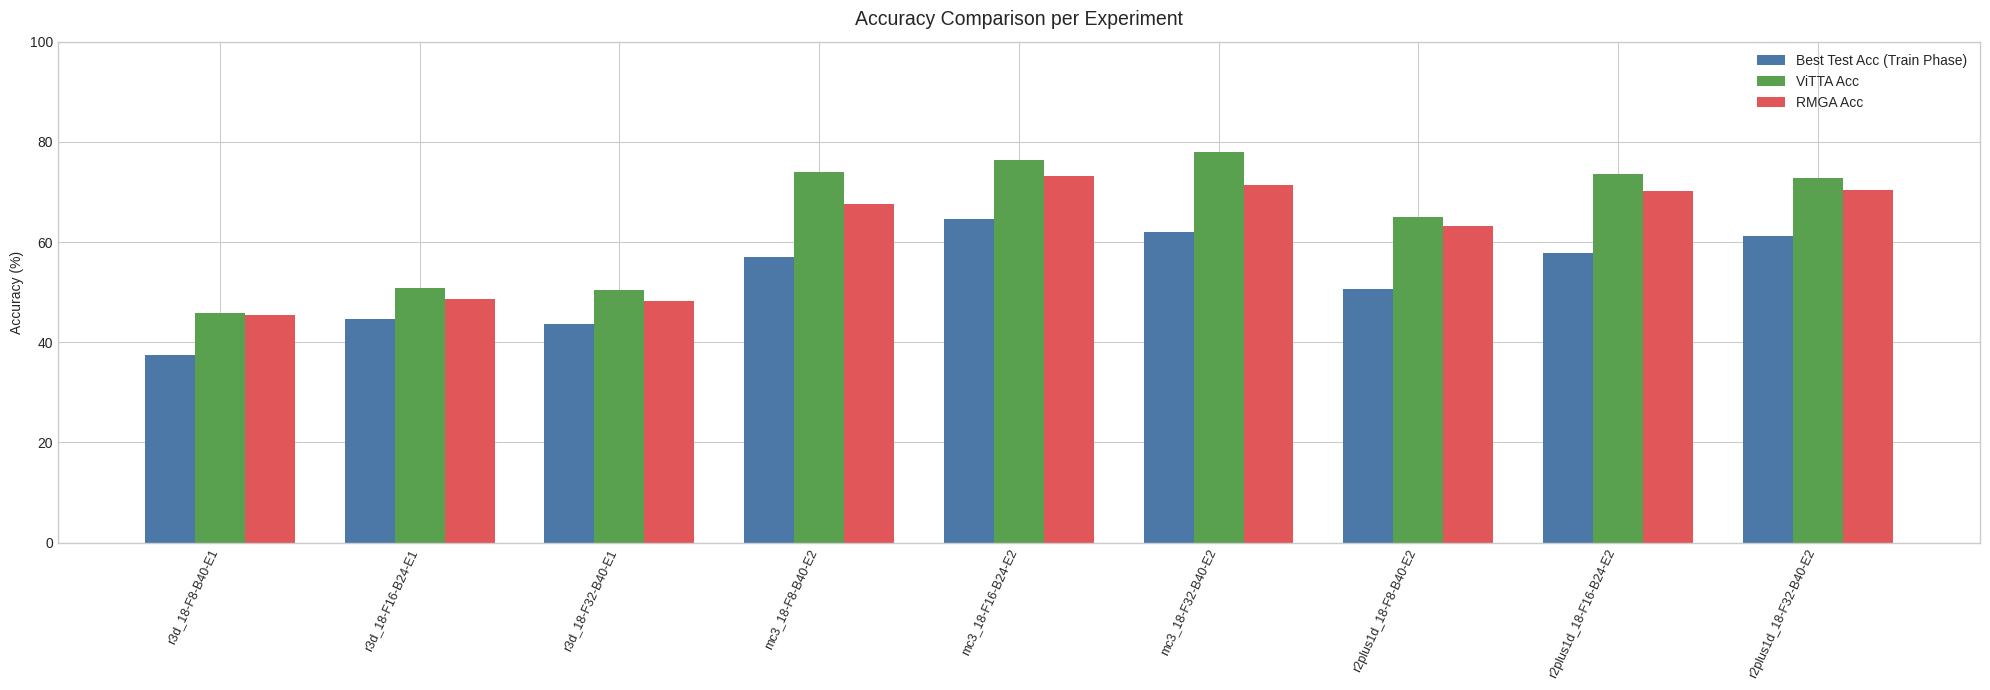

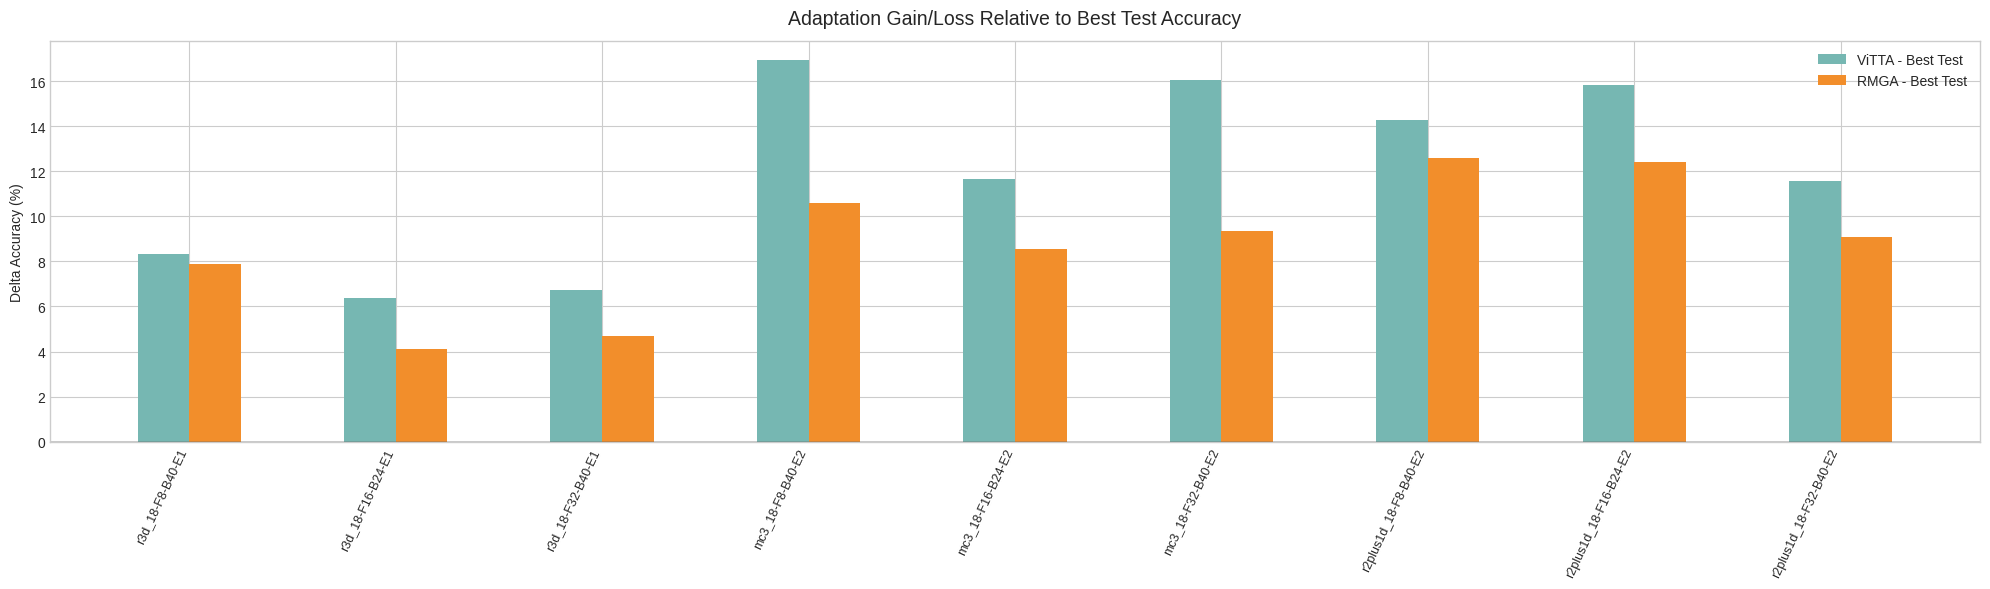

In [5]:
# 1) Grouped comparison across all experiments
fig, ax = plt.subplots(figsize=(20, 7))

x = np.arange(len(summary_df))
w = 0.25

ax.bar(x - w, summary_df["best_test_acc"], width=w, label="Best Test Acc (Train Phase)", color="#4C78A8")
ax.bar(x, summary_df["vitta_acc"], width=w, label="ViTTA Acc", color="#59A14F")
ax.bar(x + w, summary_df["rmga_acc"], width=w, label="RMGA Acc", color="#E15759")

ax.set_title("Accuracy Comparison per Experiment", fontsize=14, pad=12)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels(summary_df["short_label"], rotation=65, ha="right", fontsize=9)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

# 2) Gain charts relative to best test accuracy
fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(x - w / 2, summary_df["vitta_gain_vs_best_test"], width=w, label="ViTTA - Best Test", color="#76B7B2")
ax.bar(x + w / 2, summary_df["rmga_gain_vs_best_test"], width=w, label="RMGA - Best Test", color="#F28E2B")
ax.axhline(0, color="black", linewidth=1)

ax.set_title("Adaptation Gain/Loss Relative to Best Test Accuracy", fontsize=14, pad=12)
ax.set_ylabel("Delta Accuracy (%)")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["short_label"], rotation=65, ha="right", fontsize=9)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


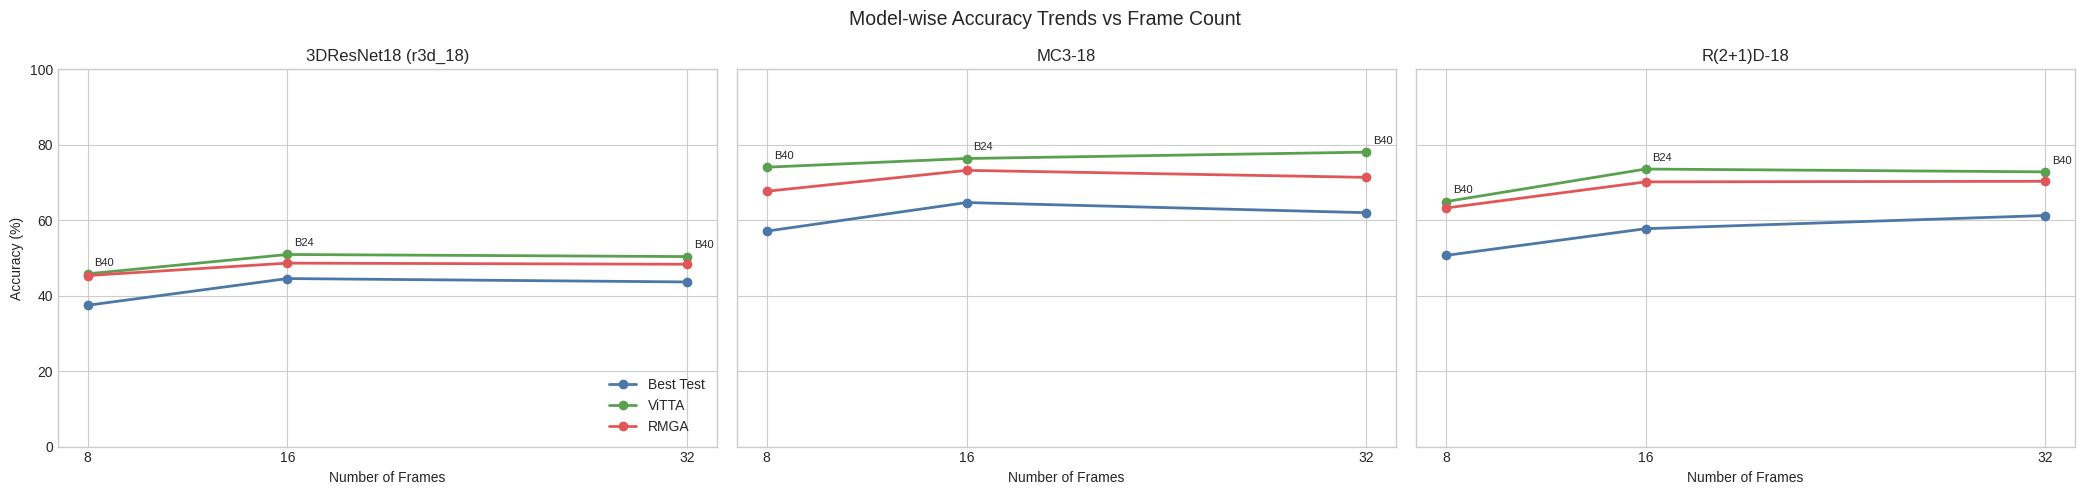

In [6]:
# 3) Frame-wise trend per model
fig, axes = plt.subplots(1, 3, figsize=(21, 5), sharey=True)
metric_specs = [
    ("best_test_acc", "Best Test", "#4C78A8"),
    ("vitta_acc", "ViTTA", "#59A14F"),
    ("rmga_acc", "RMGA", "#E15759"),
]

for ax, model in zip(axes, MODEL_ORDER):
    sub = summary_df[summary_df["model"] == model].sort_values("frames")
    if sub.empty:
        ax.set_visible(False)
        continue

    for col, name, color in metric_specs:
        ax.plot(sub["frames"], sub[col], marker="o", linewidth=2, label=name, color=color)

    for _, r in sub.iterrows():
        ax.annotate(
            f"B{int(r['batch_size'])}",
            (r["frames"], r["vitta_acc"]),
            textcoords="offset points",
            xytext=(5, 6),
            fontsize=8,
        )

    ax.set_title(MODEL_LABELS.get(model, model))
    ax.set_xlabel("Number of Frames")
    ax.set_xticks(sorted(sub["frames"].unique()))

axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 100)
axes[0].legend(loc="lower right")
fig.suptitle("Model-wise Accuracy Trends vs Frame Count", fontsize=14)
plt.tight_layout()
plt.show()


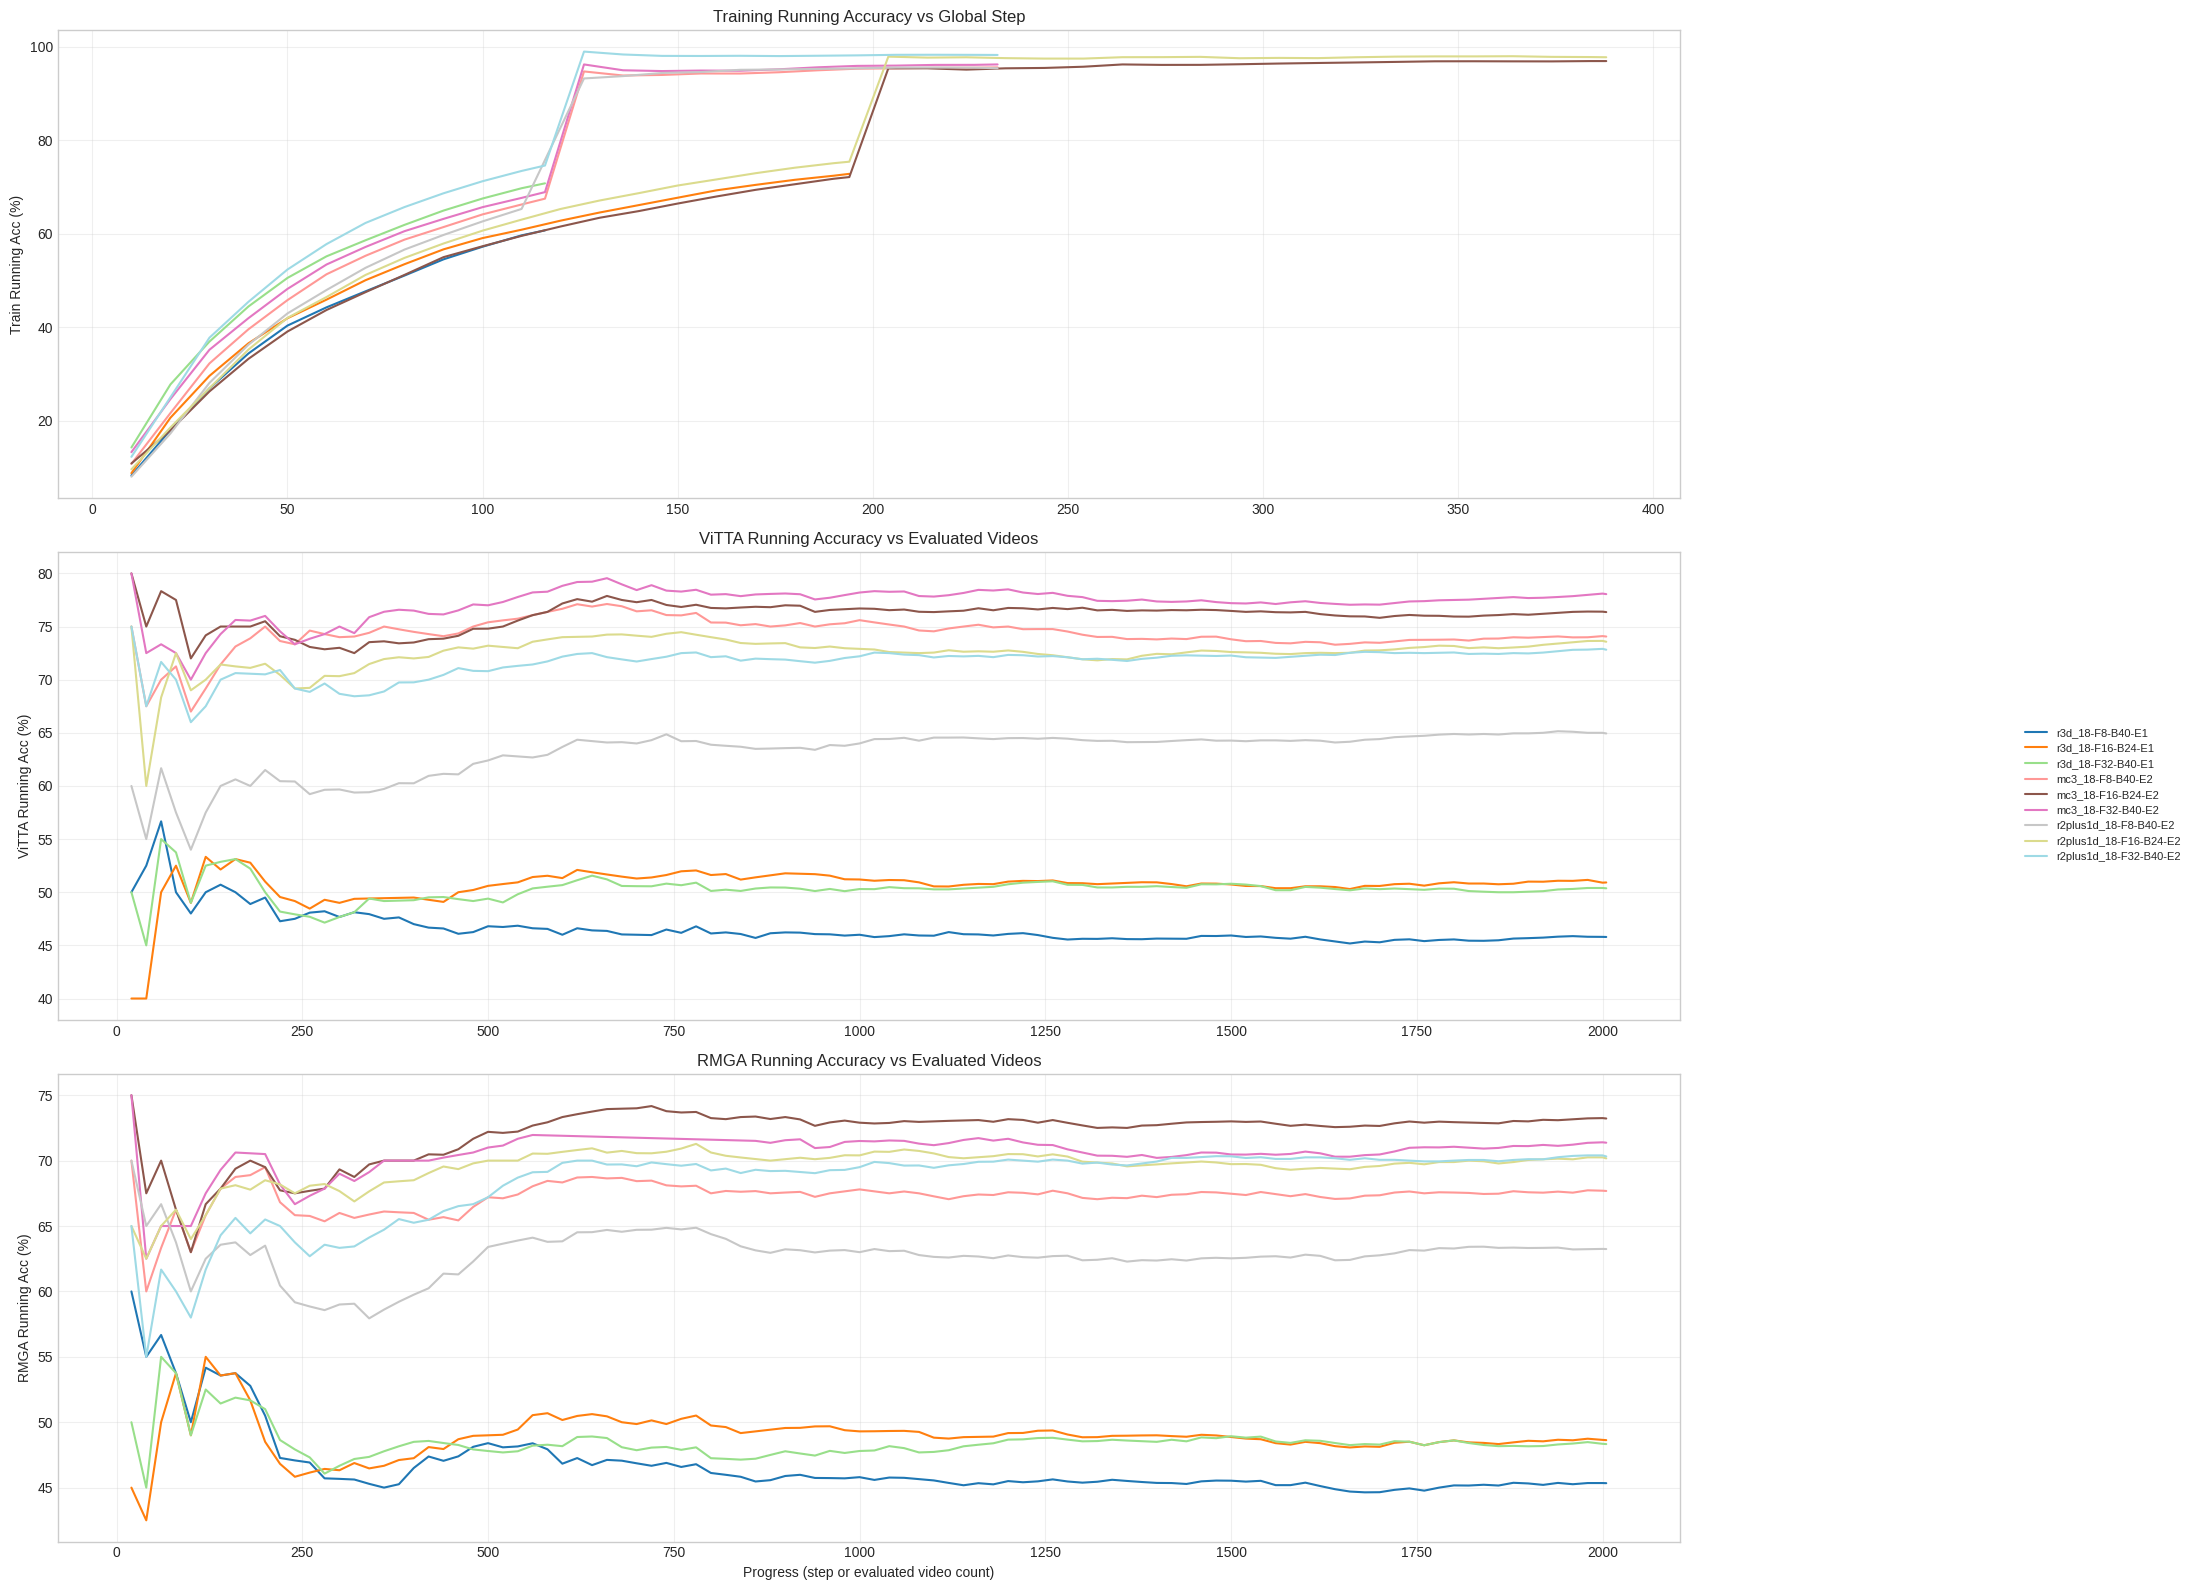

In [7]:
# 4) Running accuracy trajectories (train, ViTTA, RMGA)
fig, axes = plt.subplots(3, 1, figsize=(20, 16), sharex=False)

ordered_ids = summary_df["exp_id"].tolist()
colors = plt.cm.tab20(np.linspace(0, 1, len(ordered_ids)))
color_map = dict(zip(ordered_ids, colors))

for exp_id in ordered_ids:
    lbl = label_map[exp_id]

    tr = train_curve_df[train_curve_df["exp_id"] == exp_id]
    if not tr.empty:
        axes[0].plot(tr["global_step"], tr["acc_pct"], label=lbl, color=color_map[exp_id], linewidth=1.5)

    vt = vitta_curve_df[vitta_curve_df["exp_id"] == exp_id]
    if not vt.empty:
        axes[1].plot(vt["seen"], vt["running_acc"], label=lbl, color=color_map[exp_id], linewidth=1.5)

    rg = rmga_curve_df[rmga_curve_df["exp_id"] == exp_id]
    if not rg.empty:
        axes[2].plot(rg["seen"], rg["running_acc"], label=lbl, color=color_map[exp_id], linewidth=1.5)

axes[0].set_title("Training Running Accuracy vs Global Step")
axes[0].set_ylabel("Train Running Acc (%)")

axes[1].set_title("ViTTA Running Accuracy vs Evaluated Videos")
axes[1].set_ylabel("ViTTA Running Acc (%)")

axes[2].set_title("RMGA Running Accuracy vs Evaluated Videos")
axes[2].set_ylabel("RMGA Running Acc (%)")
axes[2].set_xlabel("Progress (step or evaluated video count)")

for ax in axes:
    ax.grid(True, alpha=0.3)

handles, labels = axes[2].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


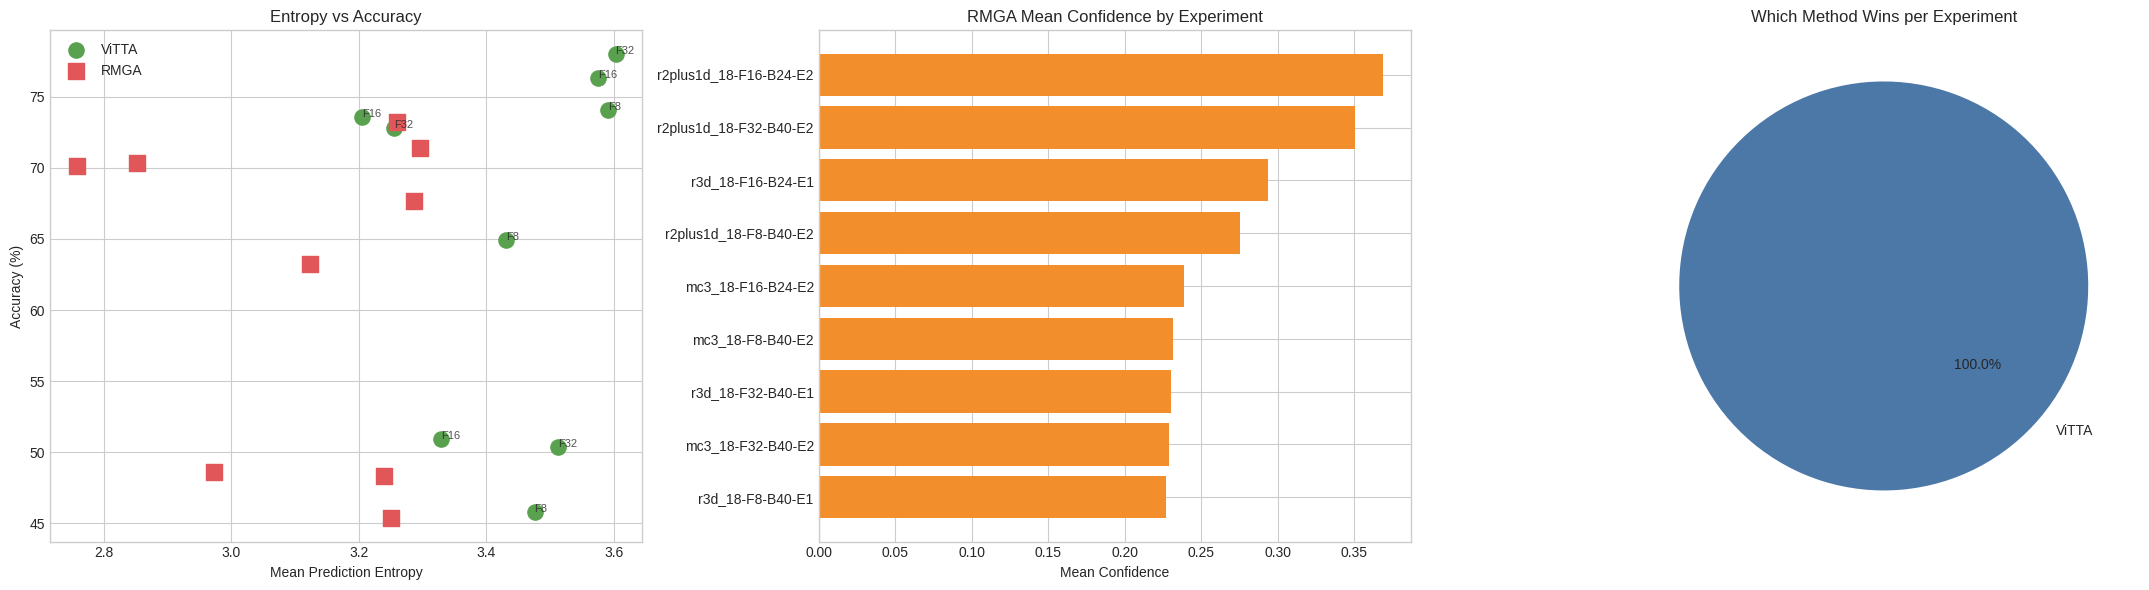

In [8]:
# 5) Entropy / confidence diagnostics + method winner distribution
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# (a) Entropy vs accuracy
axes[0].scatter(summary_df["vitta_entropy"], summary_df["vitta_acc"], c="#59A14F", s=120, marker="o", label="ViTTA")
axes[0].scatter(summary_df["rmga_entropy"], summary_df["rmga_acc"], c="#E15759", s=120, marker="s", label="RMGA")
for _, r in summary_df.iterrows():
    axes[0].annotate(f"F{int(r['frames'])}", (r["vitta_entropy"], r["vitta_acc"]), fontsize=8, alpha=0.8)
axes[0].set_title("Entropy vs Accuracy")
axes[0].set_xlabel("Mean Prediction Entropy")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()

# (b) RMGA mean confidence by experiment
sorted_conf = summary_df.sort_values("rmga_conf", ascending=False)
axes[1].barh(sorted_conf["short_label"], sorted_conf["rmga_conf"], color="#F28E2B")
axes[1].set_title("RMGA Mean Confidence by Experiment")
axes[1].set_xlabel("Mean Confidence")
axes[1].invert_yaxis()

# (c) Pie chart: best-performing evaluation method per experiment
winner_series = summary_df[["best_test_acc", "vitta_acc", "rmga_acc"]].idxmax(axis=1)
winner_map = {
    "best_test_acc": "Best Test",
    "vitta_acc": "ViTTA",
    "rmga_acc": "RMGA",
}
winner_counts = winner_series.map(winner_map).value_counts()
axes[2].pie(
    winner_counts.values,
    labels=winner_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#4C78A8", "#59A14F", "#E15759"],
)
axes[2].set_title("Which Method Wins per Experiment")

plt.tight_layout()
plt.show()


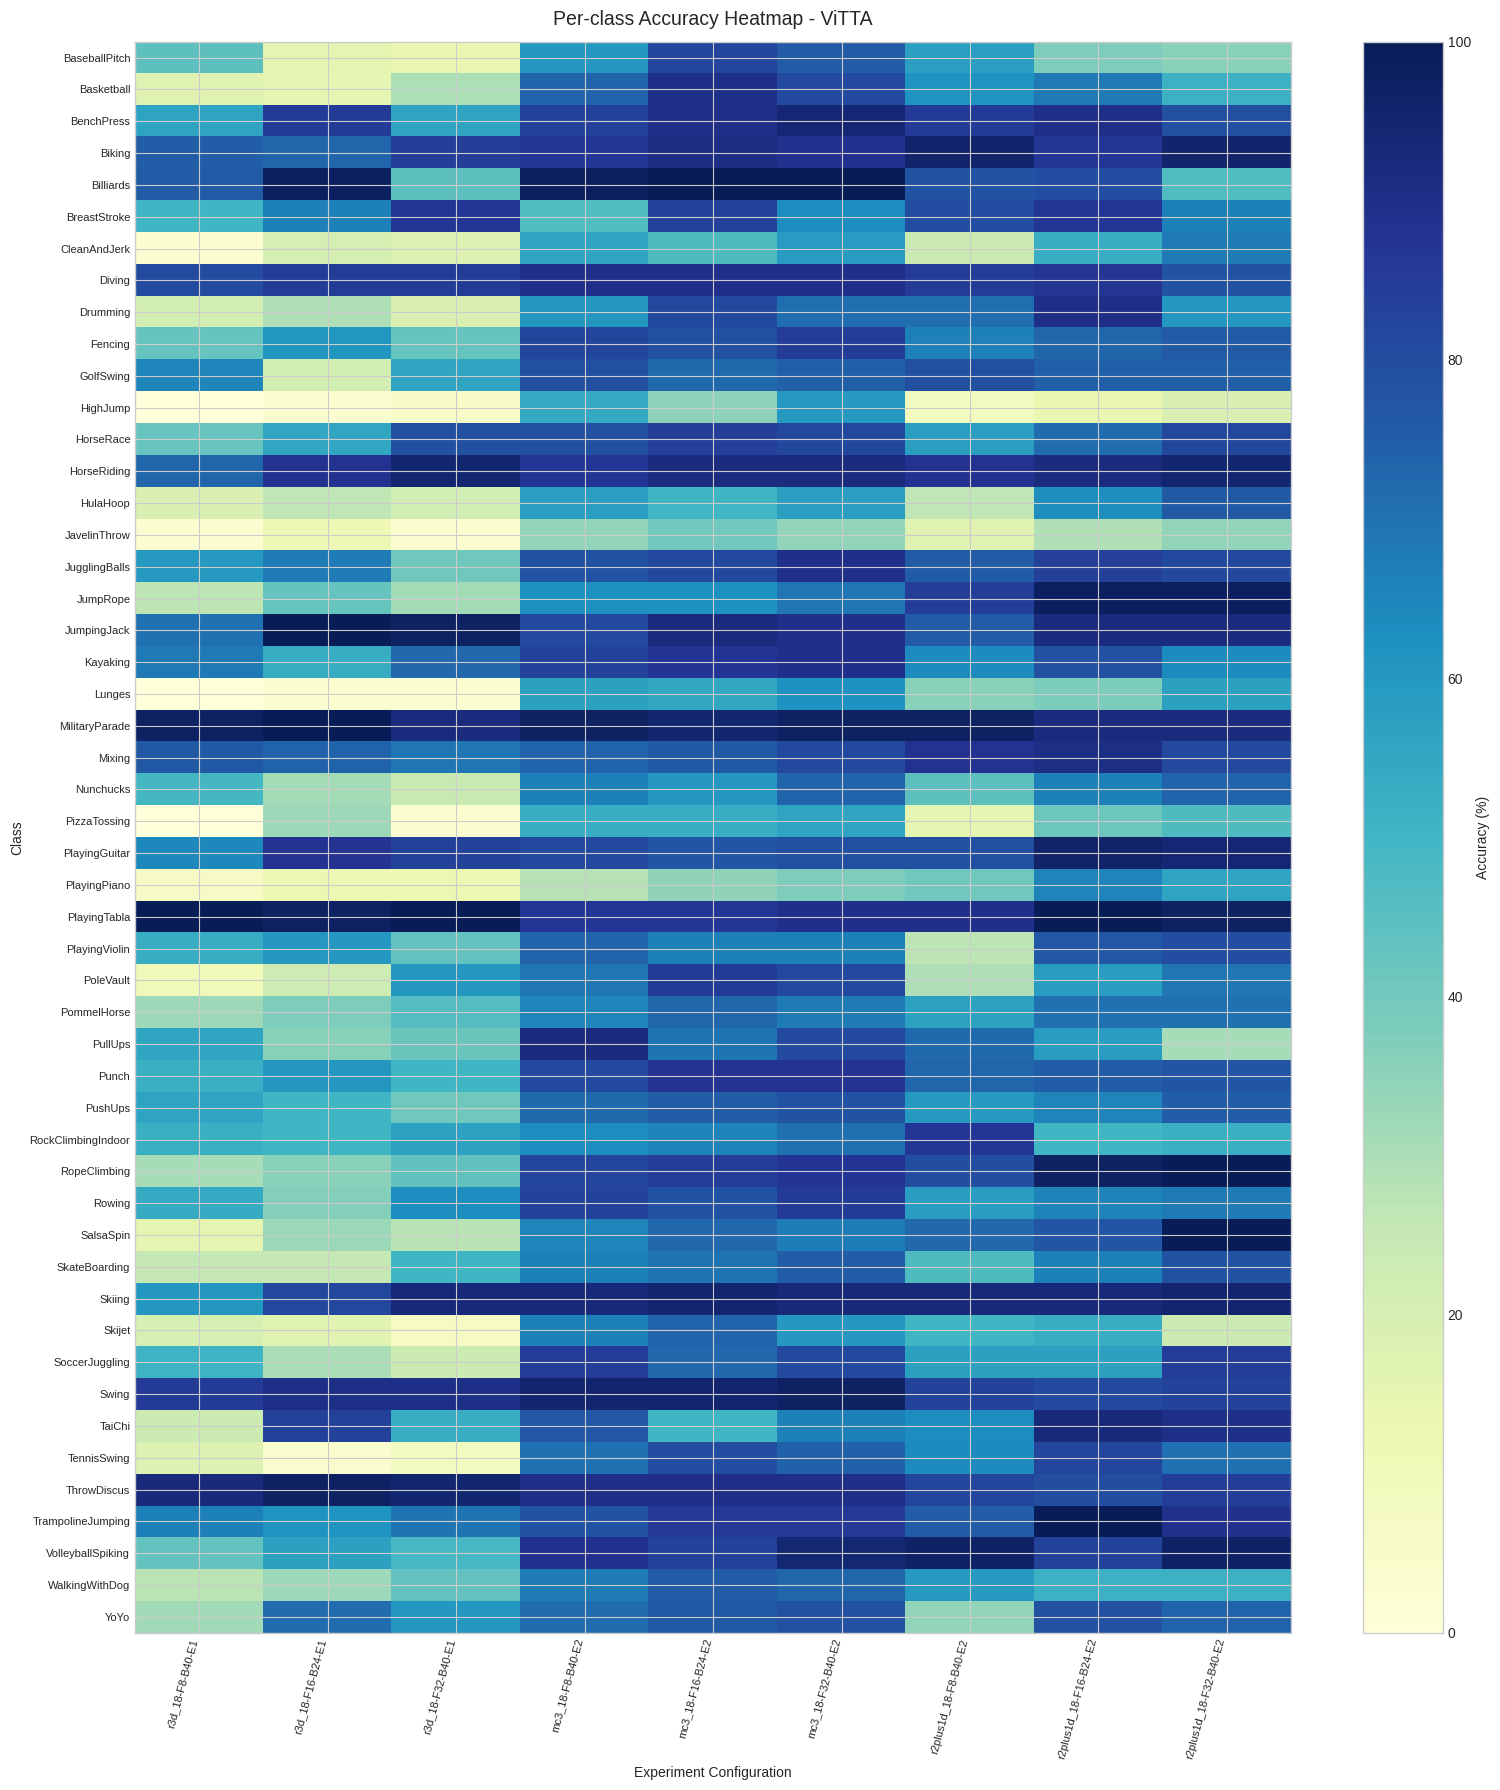

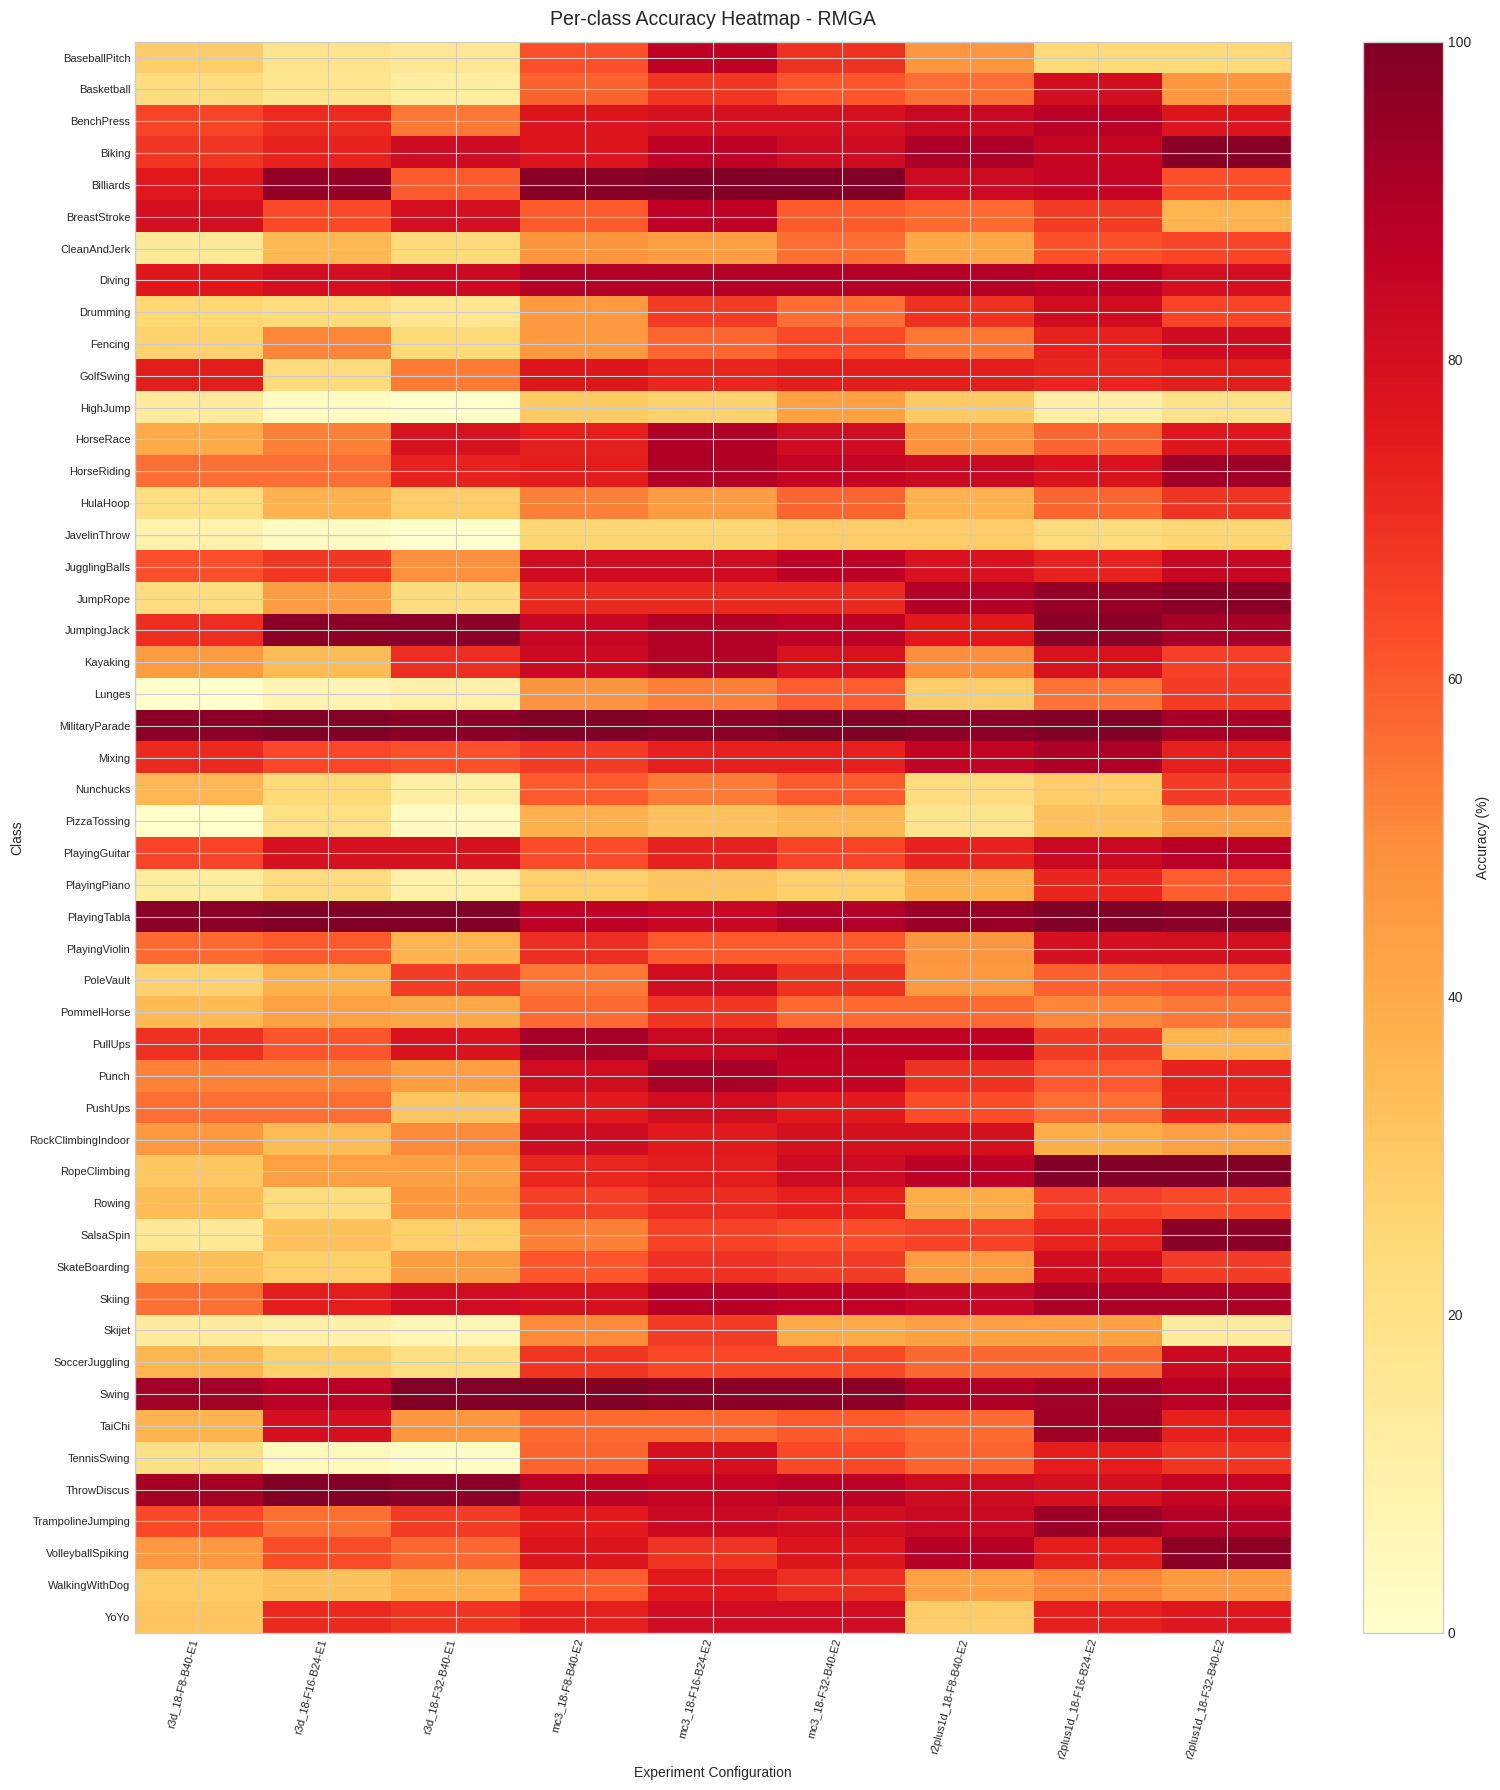

In [9]:
# 6) Per-class heatmaps (all configurations)
def plot_per_class_heatmap(perclass_df: pd.DataFrame, title: str, cmap: str = "viridis"):
    if perclass_df.empty:
        print(f"No data available for: {title}")
        return

    pivot = perclass_df.pivot_table(
        index="class_name",
        columns="short_label",
        values="acc_pct",
        aggfunc="mean",
    )

    ordered_cols = [label_map[eid] for eid in summary_df["exp_id"] if label_map[eid] in pivot.columns]
    pivot = pivot.reindex(sorted(pivot.index)).reindex(columns=ordered_cols)

    fig, ax = plt.subplots(figsize=(max(16, 1.2 * len(pivot.columns)), 18))
    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, vmin=0, vmax=100)

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=75, ha="right", fontsize=8)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel("Experiment Configuration")
    ax.set_ylabel("Class")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Accuracy (%)")

    plt.tight_layout()
    plt.show()


plot_per_class_heatmap(perclass_vitta_df, "Per-class Accuracy Heatmap - ViTTA", cmap="YlGnBu")
plot_per_class_heatmap(perclass_rmga_df, "Per-class Accuracy Heatmap - RMGA", cmap="YlOrRd")


Best ViTTA configuration per model


,model,short_label,vitta_acc,frames,batch_size,epochs
5,mc3_18,mc3_18-F32-B40-E2,78.05,32,40,2
7,r2plus1d_18,r2plus1d_18-F16-B24-E2,73.57,16,24,2
1,r3d_18,r3d_18-F16-B24-E1,50.92,16,24,1


Best RMGA configuration per model


,model,short_label,rmga_acc,frames,batch_size,epochs
4,mc3_18,mc3_18-F16-B24-E2,73.22,16,24,2
8,r2plus1d_18,r2plus1d_18-F32-B40-E2,70.32,32,40,2
1,r3d_18,r3d_18-F16-B24-E1,48.63,16,24,1


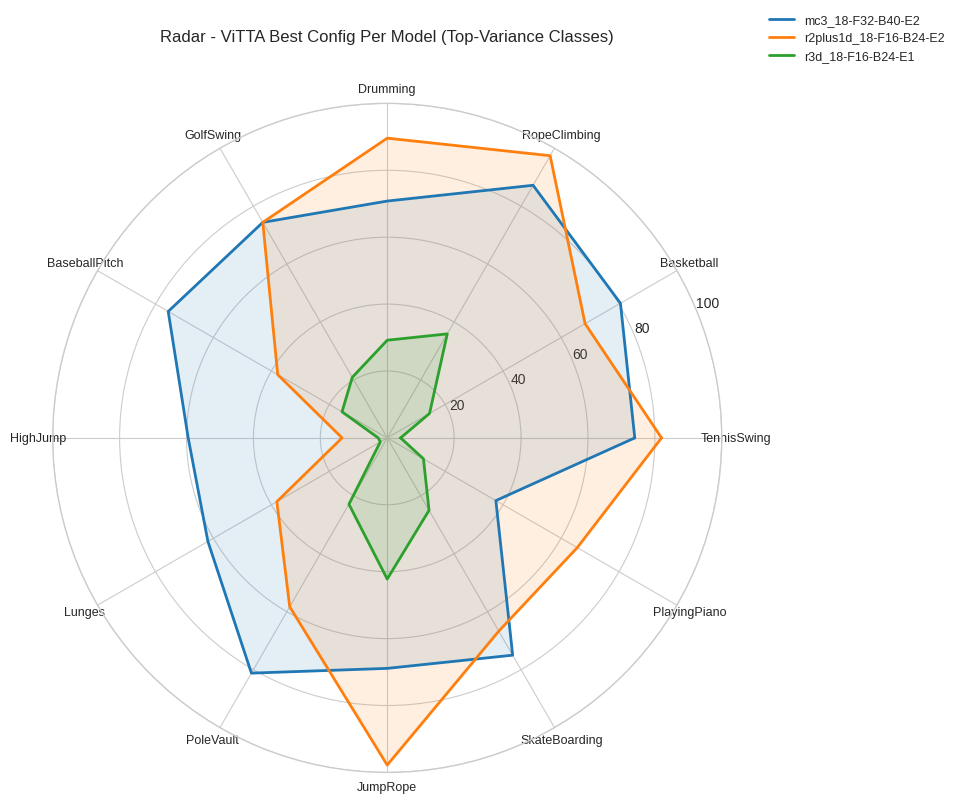

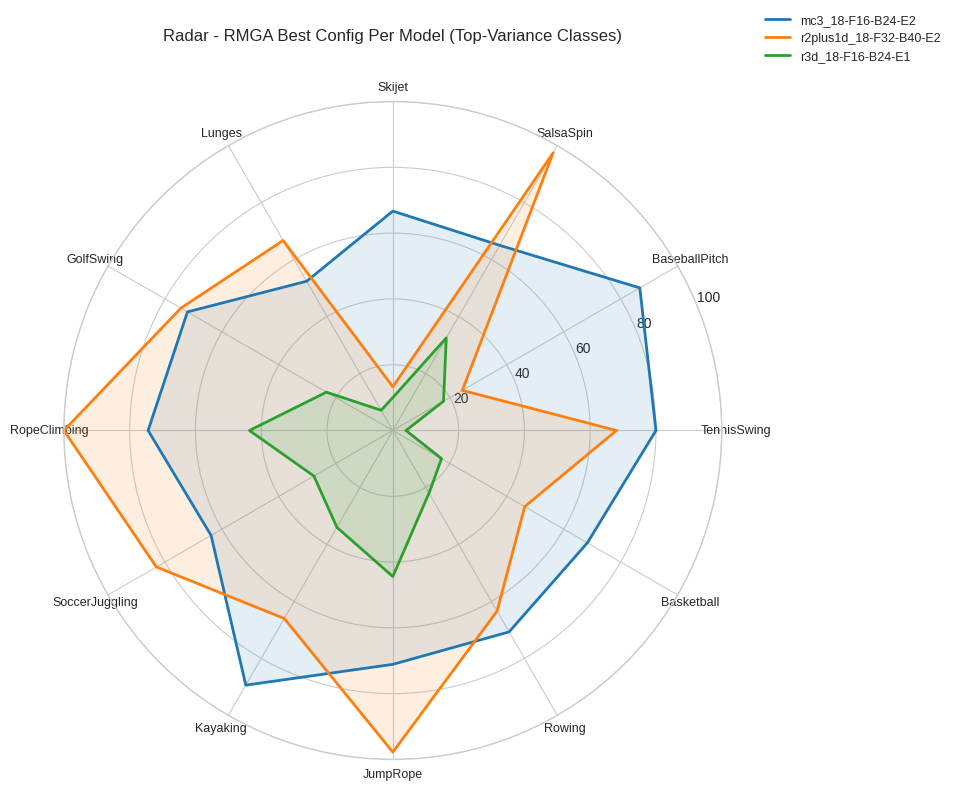

In [10]:
# 7) Best configuration per model + radar plots on most discriminative classes
best_vitta_idx = summary_df.groupby("model")["vitta_acc"].idxmax()
best_rmga_idx = summary_df.groupby("model")["rmga_acc"].idxmax()

best_vitta_cfg = summary_df.loc[best_vitta_idx, ["model", "short_label", "vitta_acc", "frames", "batch_size", "epochs"]].sort_values("model")
best_rmga_cfg = summary_df.loc[best_rmga_idx, ["model", "short_label", "rmga_acc", "frames", "batch_size", "epochs"]].sort_values("model")

print("Best ViTTA configuration per model")
display(best_vitta_cfg.round(3))
print("Best RMGA configuration per model")
display(best_rmga_cfg.round(3))


def radar_from_perclass(perclass_df: pd.DataFrame, cfg_df: pd.DataFrame, metric_col: str, title: str, top_k: int = 12):
    if perclass_df.empty or cfg_df.empty:
        print(f"No data to draw radar: {title}")
        return

    exp_ids = summary_df[summary_df["short_label"].isin(cfg_df["short_label"])]["exp_id"].tolist()
    subset = perclass_df[perclass_df["exp_id"].isin(exp_ids)]

    wide = subset.pivot_table(index="class_name", columns="short_label", values="acc_pct", aggfunc="mean")
    if wide.empty:
        print(f"No class matrix for: {title}")
        return

    # Pick classes with highest variance across selected best configs
    sel_classes = wide.std(axis=1).sort_values(ascending=False).head(top_k).index.tolist()
    wide = wide.loc[sel_classes]

    labels = wide.index.tolist()
    n = len(labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    angles = np.concatenate([angles, [angles[0]]])

    fig = plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)

    for col in wide.columns:
        vals = wide[col].values
        vals = np.concatenate([vals, [vals[0]]])
        ax.plot(angles, vals, linewidth=2, label=col)
        ax.fill(angles, vals, alpha=0.12)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_ylim(0, 100)
    ax.set_title(title, y=1.08)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
    plt.tight_layout()
    plt.show()


radar_from_perclass(
    perclass_vitta_df,
    best_vitta_cfg,
    metric_col="vitta_acc",
    title="Radar - ViTTA Best Config Per Model (Top-Variance Classes)",
)

radar_from_perclass(
    perclass_rmga_df,
    best_rmga_cfg,
    metric_col="rmga_acc",
    title="Radar - RMGA Best Config Per Model (Top-Variance Classes)",
)


Top experiments by Best Test Accuracy


,short_label,best_test_acc,vitta_acc,rmga_acc
4,mc3_18-F16-B24-E2,64.69,76.36,73.22
5,mc3_18-F32-B40-E2,62.00,78.05,71.37
8,r2plus1d_18-F32-B40-E2,61.25,72.82,70.32
7,r2plus1d_18-F16-B24-E2,57.76,73.57,70.17
3,mc3_18-F8-B40-E2,57.11,74.06,67.68


Top experiments by ViTTA Accuracy


,short_label,best_test_acc,vitta_acc,rmga_acc
5,mc3_18-F32-B40-E2,62.00,78.05,71.37
4,mc3_18-F16-B24-E2,64.69,76.36,73.22
3,mc3_18-F8-B40-E2,57.11,74.06,67.68
7,r2plus1d_18-F16-B24-E2,57.76,73.57,70.17
8,r2plus1d_18-F32-B40-E2,61.25,72.82,70.32


Top experiments by RMGA Accuracy


,short_label,best_test_acc,vitta_acc,rmga_acc
4,mc3_18-F16-B24-E2,64.69,76.36,73.22
5,mc3_18-F32-B40-E2,62.00,78.05,71.37
8,r2plus1d_18-F32-B40-E2,61.25,72.82,70.32
7,r2plus1d_18-F16-B24-E2,57.76,73.57,70.17
3,mc3_18-F8-B40-E2,57.11,74.06,67.68


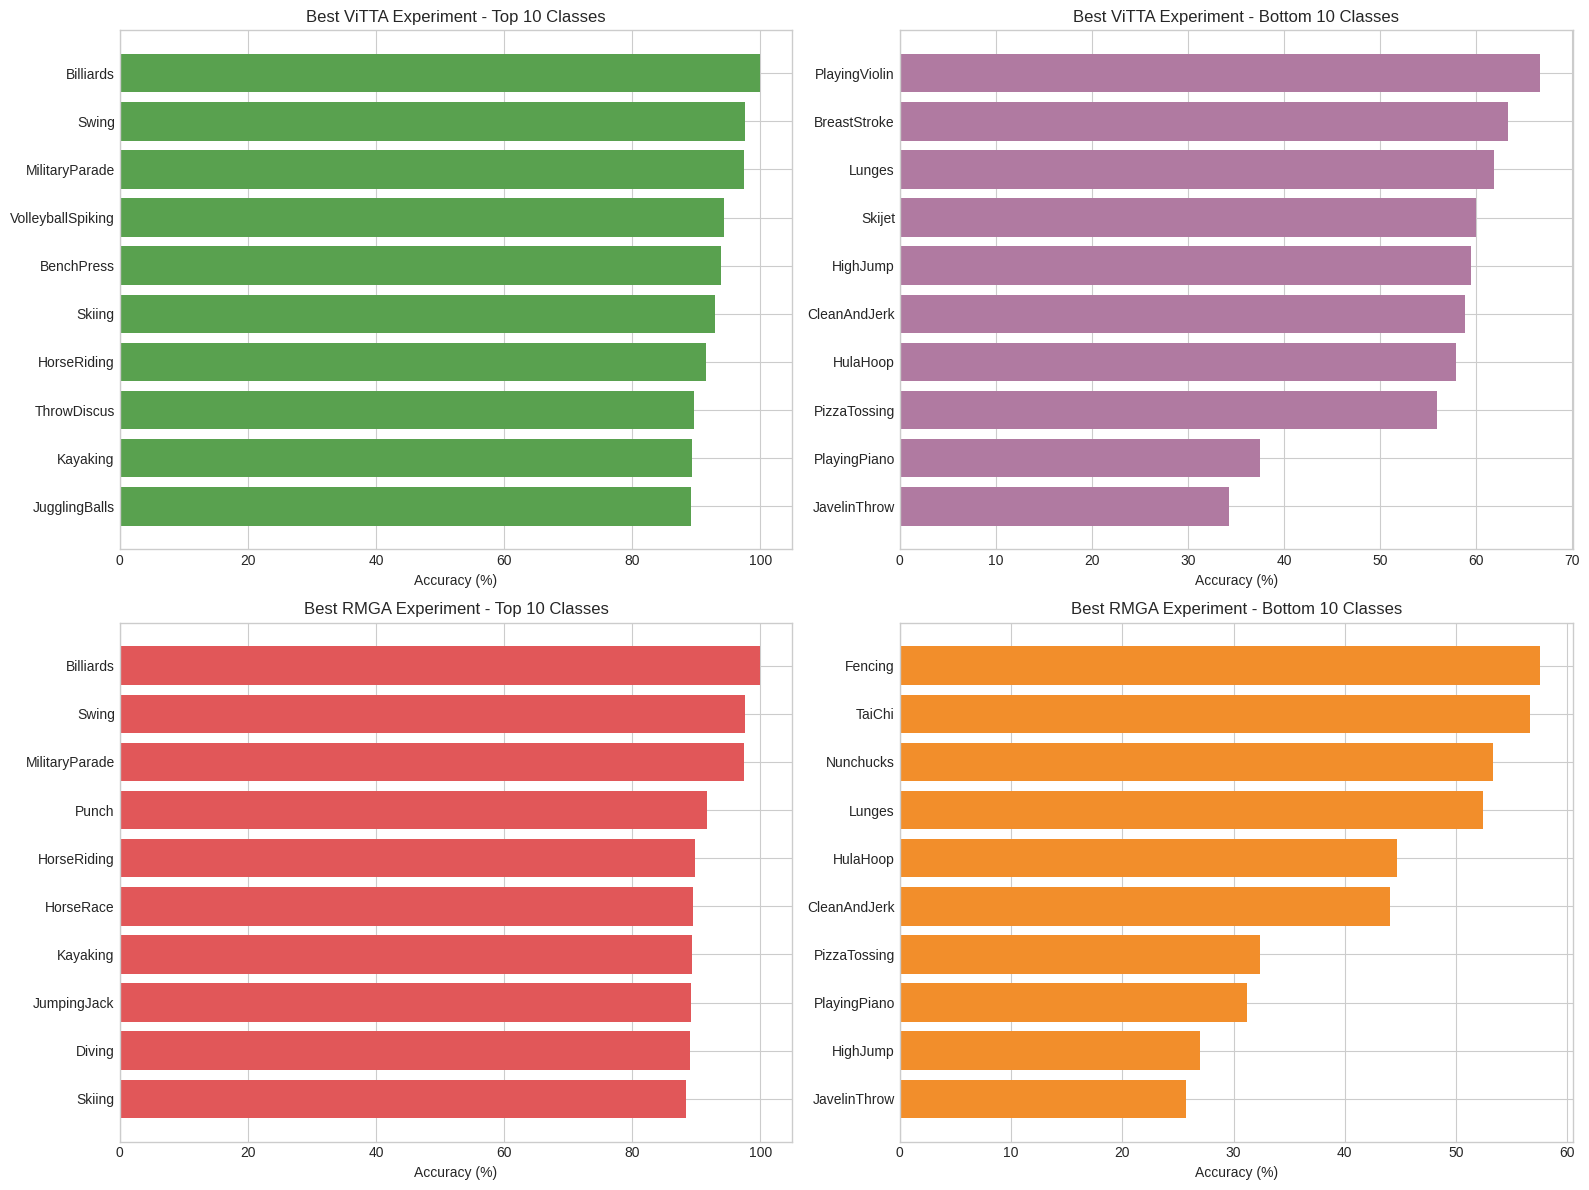

In [11]:
# 8) Leaderboards and class-level strongest / weakest snapshots
print("Top experiments by Best Test Accuracy")
display(summary_df.nlargest(5, "best_test_acc")[["short_label", "best_test_acc", "vitta_acc", "rmga_acc"]].round(3))

print("Top experiments by ViTTA Accuracy")
display(summary_df.nlargest(5, "vitta_acc")[["short_label", "best_test_acc", "vitta_acc", "rmga_acc"]].round(3))

print("Top experiments by RMGA Accuracy")
display(summary_df.nlargest(5, "rmga_acc")[["short_label", "best_test_acc", "vitta_acc", "rmga_acc"]].round(3))

best_vitta_exp = summary_df.loc[summary_df["vitta_acc"].idxmax(), "exp_id"]
best_rmga_exp = summary_df.loc[summary_df["rmga_acc"].idxmax(), "exp_id"]

vitta_best_classes = (
    perclass_vitta_df[perclass_vitta_df["exp_id"] == best_vitta_exp]
    .sort_values("acc_pct", ascending=False)
)
rmga_best_classes = (
    perclass_rmga_df[perclass_rmga_df["exp_id"] == best_rmga_exp]
    .sort_values("acc_pct", ascending=False)
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].barh(vitta_best_classes.head(10)["class_name"], vitta_best_classes.head(10)["acc_pct"], color="#59A14F")
axes[0, 0].set_title("Best ViTTA Experiment - Top 10 Classes")
axes[0, 0].invert_yaxis()

axes[0, 1].barh(vitta_best_classes.tail(10)["class_name"], vitta_best_classes.tail(10)["acc_pct"], color="#B07AA1")
axes[0, 1].set_title("Best ViTTA Experiment - Bottom 10 Classes")
axes[0, 1].invert_yaxis()

axes[1, 0].barh(rmga_best_classes.head(10)["class_name"], rmga_best_classes.head(10)["acc_pct"], color="#E15759")
axes[1, 0].set_title("Best RMGA Experiment - Top 10 Classes")
axes[1, 0].invert_yaxis()

axes[1, 1].barh(rmga_best_classes.tail(10)["class_name"], rmga_best_classes.tail(10)["acc_pct"], color="#F28E2B")
axes[1, 1].set_title("Best RMGA Experiment - Bottom 10 Classes")
axes[1, 1].invert_yaxis()

for ax in axes.flatten():
    ax.set_xlabel("Accuracy (%)")

plt.tight_layout()
plt.show()


## Required

This section generates the four required publication-style figures and saves them as high-resolution SVG files.

Saved output folder:
- `required_figures_svg/`

Figures:
1. Training convergence figure (loss and accuracy, one representative curve per architecture)
2. Temporal ablation figure (frames vs baseline test accuracy)
3. Adaptation comparison figure (Baseline vs ViTTA vs RMGA, plus entropy/confidence panel)
4. Per-class improvement figure (RMGA - ViTTA delta by class)

In [12]:
# Required figure export settings
from pathlib import Path

OUT_DIR = LOG_DIR / "required_figures_svg"
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXPORT_DPI = 1200  # Requested high-resolution export target

# Representative run selection: best baseline test accuracy per architecture
rep_idx = summary_df.groupby("model")["best_test_acc"].idxmax()
rep_df = summary_df.loc[rep_idx].copy().sort_values("model_sort")
rep_ids = rep_df["exp_id"].tolist()

print("Representative experiments used for convergence curves:")
for _, r in rep_df.iterrows():
    print(
        f" - {r['model']} | frames={int(r['frames'])}, batch={int(r['batch_size'])}, epochs={int(r['epochs'])}, best_test={r['best_test_acc']:.2f}%"
    )

saved_files = []


Representative experiments used for convergence curves:
 - r3d_18 | frames=16, batch=24, epochs=1, best_test=44.54%
 - mc3_18 | frames=16, batch=24, epochs=2, best_test=64.69%
 - r2plus1d_18 | frames=32, batch=40, epochs=2, best_test=61.25%


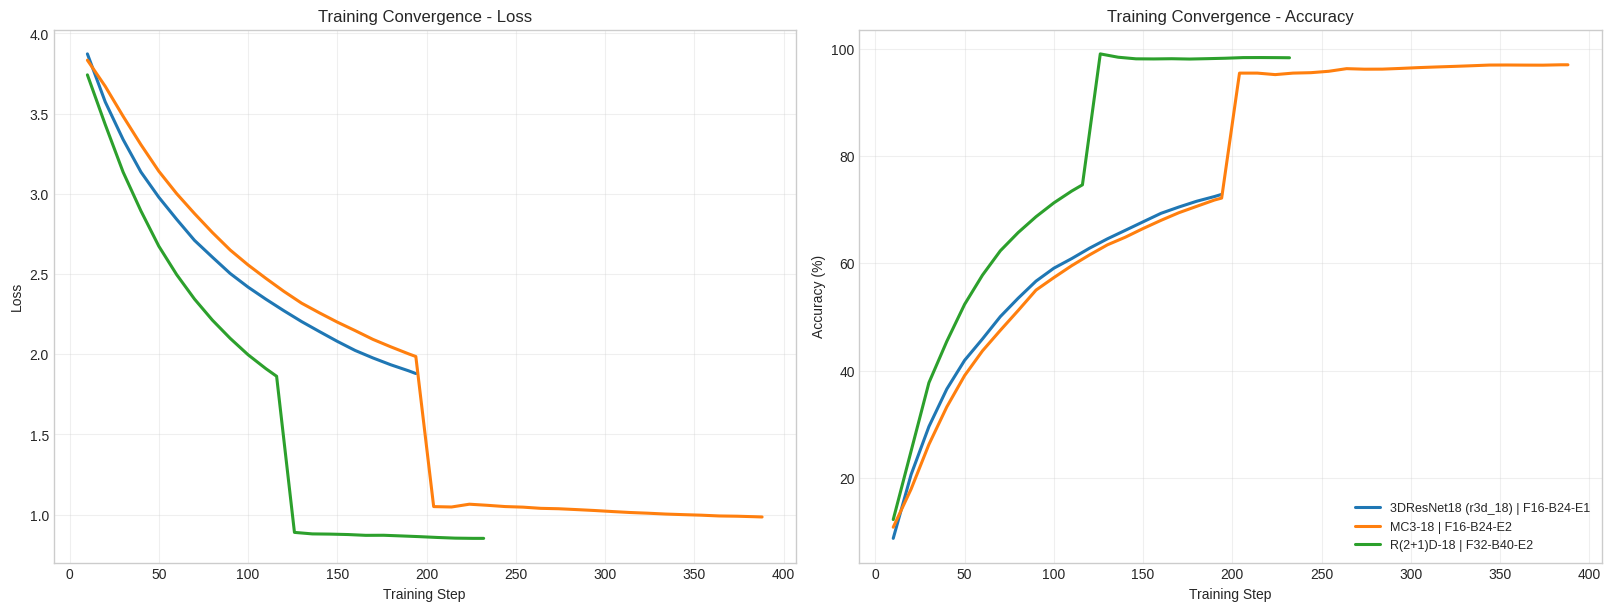

Saved: required_figures_svg/01_training_convergence.svg


In [13]:
# (i) Training convergence figure: one representative run per architecture
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

for exp_id in rep_ids:
    meta = summary_df[summary_df["exp_id"] == exp_id].iloc[0]
    sub = train_curve_df[train_curve_df["exp_id"] == exp_id].sort_values("global_step")
    if sub.empty:
        continue

    label = f"{MODEL_LABELS.get(meta['model'], meta['model'])} | F{int(meta['frames'])}-B{int(meta['batch_size'])}-E{int(meta['epochs'])}"
    axes[0].plot(sub["global_step"], sub["loss"], linewidth=2.2, label=label)
    axes[1].plot(sub["global_step"], sub["acc_pct"], linewidth=2.2, label=label)

axes[0].set_title("Training Convergence - Loss")
axes[0].set_xlabel("Training Step")
axes[0].set_ylabel("Loss")

axes[1].set_title("Training Convergence - Accuracy")
axes[1].set_xlabel("Training Step")
axes[1].set_ylabel("Accuracy (%)")

for ax in axes:
    ax.grid(True, alpha=0.3)

axes[1].legend(loc="lower right", fontsize=9)

f1 = OUT_DIR / "01_training_convergence.svg"
fig.savefig(f1, format="svg", dpi=EXPORT_DPI, bbox_inches="tight")
saved_files.append(str(f1))
plt.show()
print(f"Saved: {f1}")


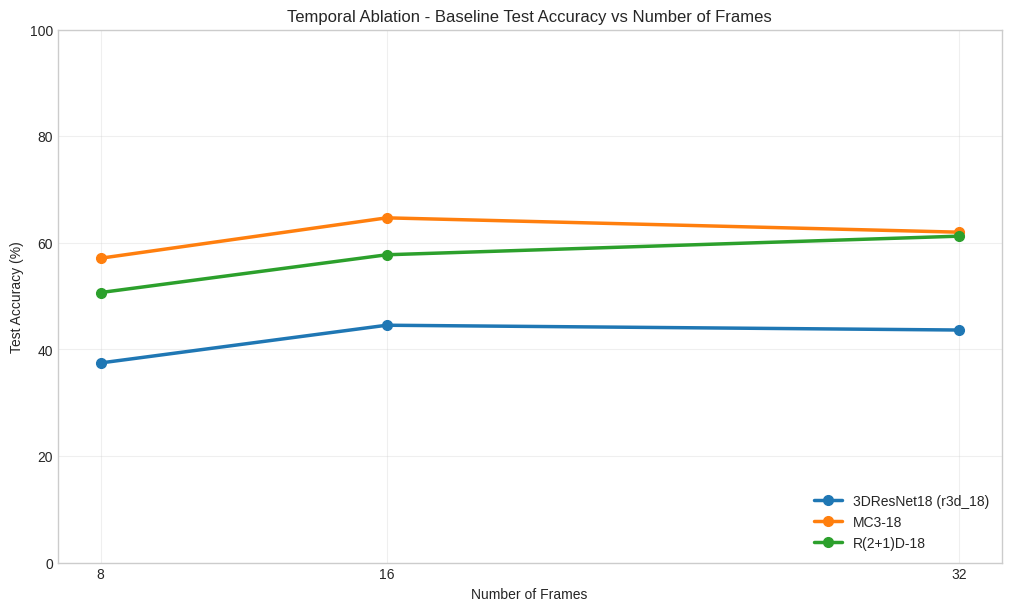

Saved: required_figures_svg/02_temporal_ablation_baseline_test_accuracy.svg


In [14]:
# (ii) Temporal ablation figure: frame count vs baseline test accuracy
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

for model in MODEL_ORDER:
    sub = summary_df[summary_df["model"] == model].sort_values("frames")
    if sub.empty:
        continue
    ax.plot(
        sub["frames"],
        sub["best_test_acc"],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=MODEL_LABELS.get(model, model),
    )

ax.set_title("Temporal Ablation - Baseline Test Accuracy vs Number of Frames")
ax.set_xlabel("Number of Frames")
ax.set_ylabel("Test Accuracy (%)")
ax.set_xticks([8, 16, 32])
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")

f2 = OUT_DIR / "02_temporal_ablation_baseline_test_accuracy.svg"
fig.savefig(f2, format="svg", dpi=EXPORT_DPI, bbox_inches="tight")
saved_files.append(str(f2))
plt.show()
print(f"Saved: {f2}")


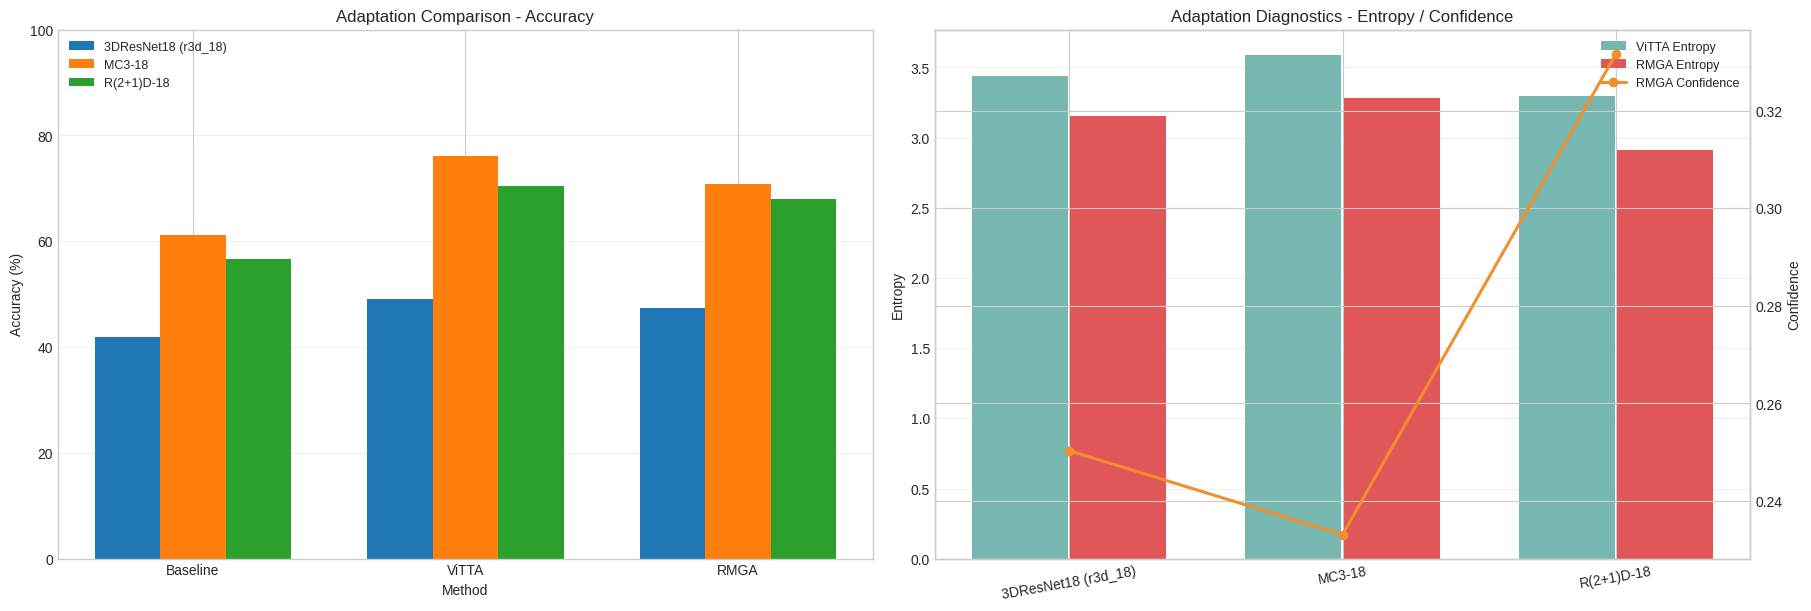

Saved: required_figures_svg/03_adaptation_comparison_accuracy_entropy_confidence.svg


In [15]:
# (iii) Adaptation comparison figure: Baseline vs ViTTA vs RMGA (+ entropy/confidence panel)
method_cols = {
    "Baseline": "best_test_acc",
    "ViTTA": "vitta_acc",
    "RMGA": "rmga_acc",
}

acc_by_model = summary_df.groupby("model")[list(method_cols.values())].mean().reindex(MODEL_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

# Panel A: grouped bars by method, one bar per architecture
methods = list(method_cols.keys())
x = np.arange(len(methods))
bar_w = 0.24

for i, model in enumerate(MODEL_ORDER):
    vals = [acc_by_model.loc[model, method_cols[m]] for m in methods]
    axes[0].bar(x + (i - 1) * bar_w, vals, width=bar_w, label=MODEL_LABELS.get(model, model))

axes[0].set_title("Adaptation Comparison - Accuracy")
axes[0].set_xlabel("Method")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].set_ylim(0, 100)
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].legend(fontsize=9, loc="upper left")

# Panel B: entropy and confidence by architecture
diag = summary_df.groupby("model")[["vitta_entropy", "rmga_entropy", "rmga_conf"]].mean().reindex(MODEL_ORDER)
xb = np.arange(len(MODEL_ORDER))

axes[1].bar(xb - 0.18, diag["vitta_entropy"], width=0.35, label="ViTTA Entropy", color="#76B7B2")
axes[1].bar(xb + 0.18, diag["rmga_entropy"], width=0.35, label="RMGA Entropy", color="#E15759")
axes[1].set_xticks(xb)
axes[1].set_xticklabels([MODEL_LABELS.get(m, m) for m in MODEL_ORDER], rotation=10)
axes[1].set_ylabel("Entropy")
axes[1].set_title("Adaptation Diagnostics - Entropy / Confidence")
axes[1].grid(True, axis="y", alpha=0.3)

ax2 = axes[1].twinx()
ax2.plot(xb, diag["rmga_conf"], color="#F28E2B", marker="o", linewidth=2.2, label="RMGA Confidence")
ax2.set_ylabel("Confidence")

h1, l1 = axes[1].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[1].legend(h1 + h2, l1 + l2, loc="upper right", fontsize=9)

f3 = OUT_DIR / "03_adaptation_comparison_accuracy_entropy_confidence.svg"
fig.savefig(f3, format="svg", dpi=EXPORT_DPI, bbox_inches="tight")
saved_files.append(str(f3))
plt.show()
print(f"Saved: {f3}")


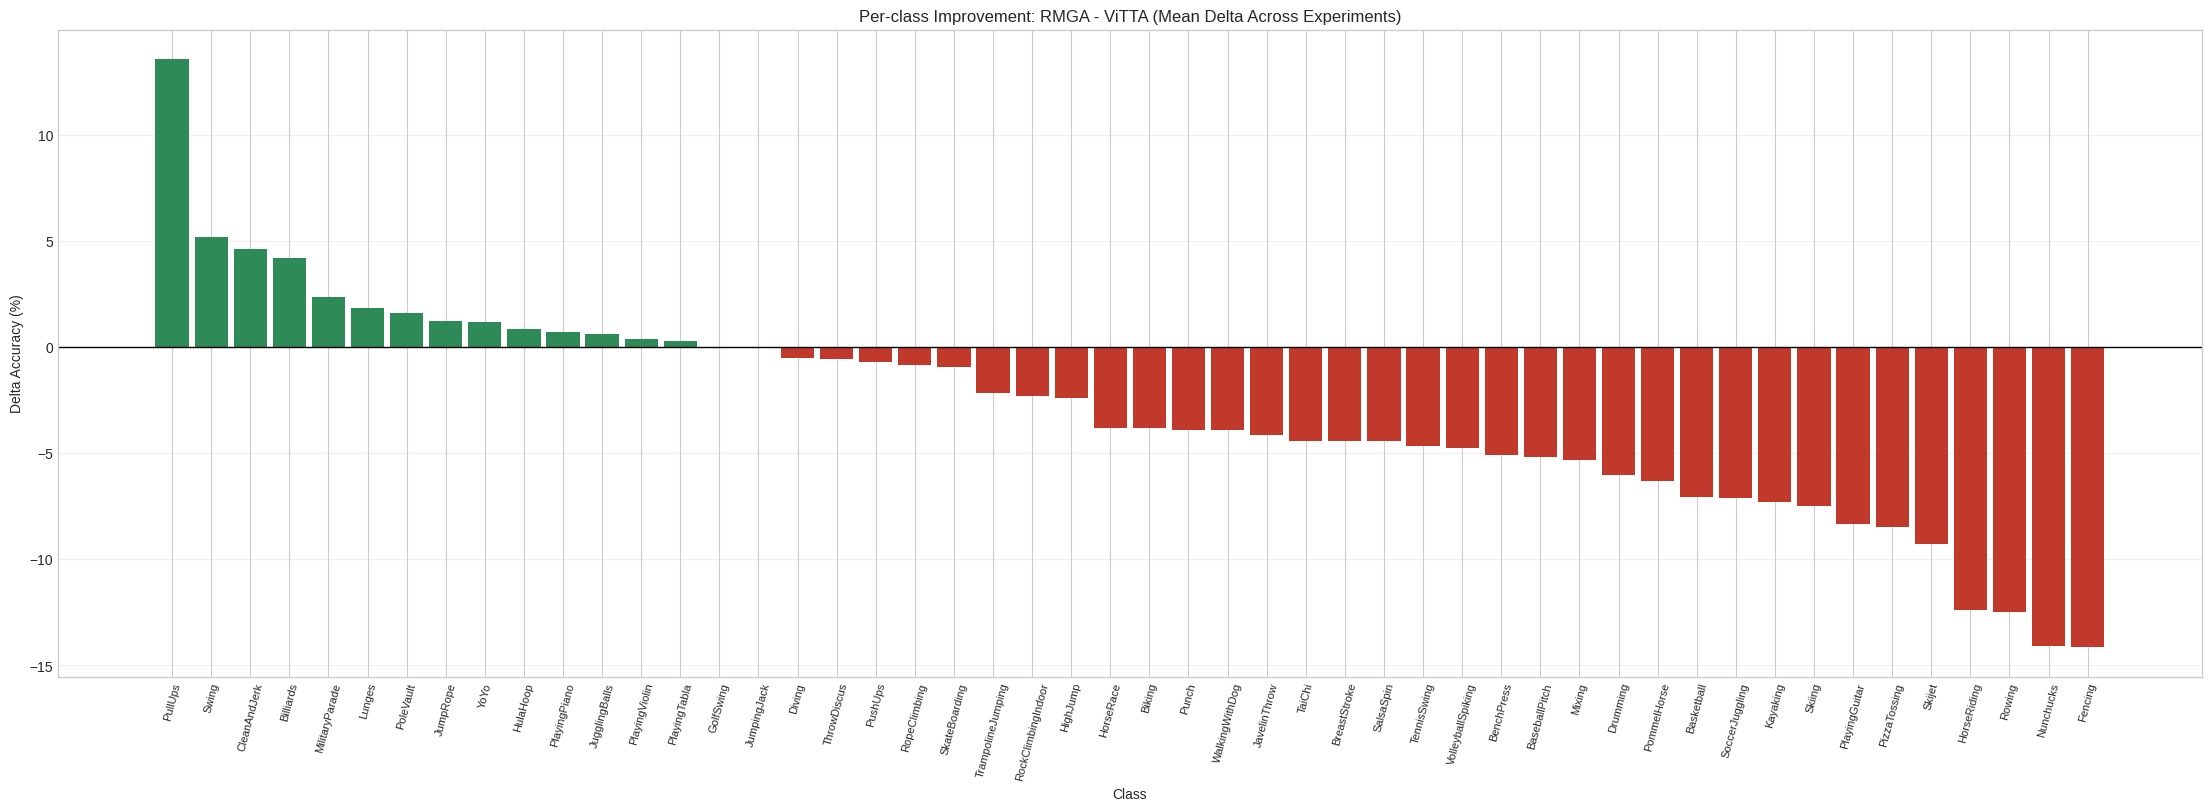

Saved: required_figures_svg/04_per_class_improvement_rmga_minus_vitta.svg

Saved required SVG files:
 - required_figures_svg/01_training_convergence.svg
 - required_figures_svg/02_temporal_ablation_baseline_test_accuracy.svg
 - required_figures_svg/03_adaptation_comparison_accuracy_entropy_confidence.svg
 - required_figures_svg/04_per_class_improvement_rmga_minus_vitta.svg


In [16]:
# (iv) Per-class improvement figure: RMGA - ViTTA delta by class
vitta_cls = perclass_vitta_df[["exp_id", "class_name", "acc_pct"]].rename(columns={"acc_pct": "vitta_acc"})
rmga_cls = perclass_rmga_df[["exp_id", "class_name", "acc_pct"]].rename(columns={"acc_pct": "rmga_acc"})

delta_df = vitta_cls.merge(rmga_cls, on=["exp_id", "class_name"], how="inner")
delta_df["delta_rmga_minus_vitta"] = delta_df["rmga_acc"] - delta_df["vitta_acc"]

class_delta = (
    delta_df.groupby("class_name")["delta_rmga_minus_vitta"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(22, 8), constrained_layout=True)
colors = np.where(class_delta.values >= 0, "#2E8B57", "#C0392B")
ax.bar(class_delta.index, class_delta.values, color=colors, width=0.85)
ax.axhline(0, color="black", linewidth=1)

ax.set_title("Per-class Improvement: RMGA - ViTTA (Mean Delta Across Experiments)")
ax.set_xlabel("Class")
ax.set_ylabel("Delta Accuracy (%)")
ax.tick_params(axis="x", rotation=75, labelsize=8)
ax.grid(True, axis="y", alpha=0.3)

f4 = OUT_DIR / "04_per_class_improvement_rmga_minus_vitta.svg"
fig.savefig(f4, format="svg", dpi=EXPORT_DPI, bbox_inches="tight")
saved_files.append(str(f4))
plt.show()
print(f"Saved: {f4}")

print("\nSaved required SVG files:")
for p in saved_files:
    print(" -", p)


## professional

This section adds publication-oriented visualizations suitable for an ML research paper. The figures emphasize:

- Main method comparison with uncertainty-aware presentation
- Temporal behavior across frame lengths and adaptation methods
- Accuracy-entropy tradeoffs for test-time adaptation
- Class-level adaptation effects summarized by architecture

All outputs are saved as high-resolution SVG files in `professional_figures_svg/`.

In [17]:
# Professional plotting setup
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk", palette="colorblind")

PRO_OUT_DIR = LOG_DIR / "professional_figures_svg"
PRO_OUT_DIR.mkdir(parents=True, exist_ok=True)
PRO_DPI = 1200

method_label_map = {
    "best_test_acc": "Baseline",
    "vitta_acc": "ViTTA",
    "rmga_acc": "RMGA",
}

model_order_labels = [MODEL_LABELS.get(m, m) for m in MODEL_ORDER]

paper_long = summary_df.melt(
    id_vars=["exp_id", "model", "model_label", "frames", "batch_size", "epochs"],
    value_vars=["best_test_acc", "vitta_acc", "rmga_acc"],
    var_name="method_key",
    value_name="accuracy",
)
paper_long["method"] = paper_long["method_key"].map(method_label_map)
paper_long["model_label"] = pd.Categorical(
    paper_long["model_label"],
    categories=model_order_labels,
    ordered=True,
)
paper_long["method"] = pd.Categorical(
    paper_long["method"],
    categories=["Baseline", "ViTTA", "RMGA"],
    ordered=True,
)

pro_saved_files = []
print("Professional output folder:", PRO_OUT_DIR)


Professional output folder: professional_figures_svg


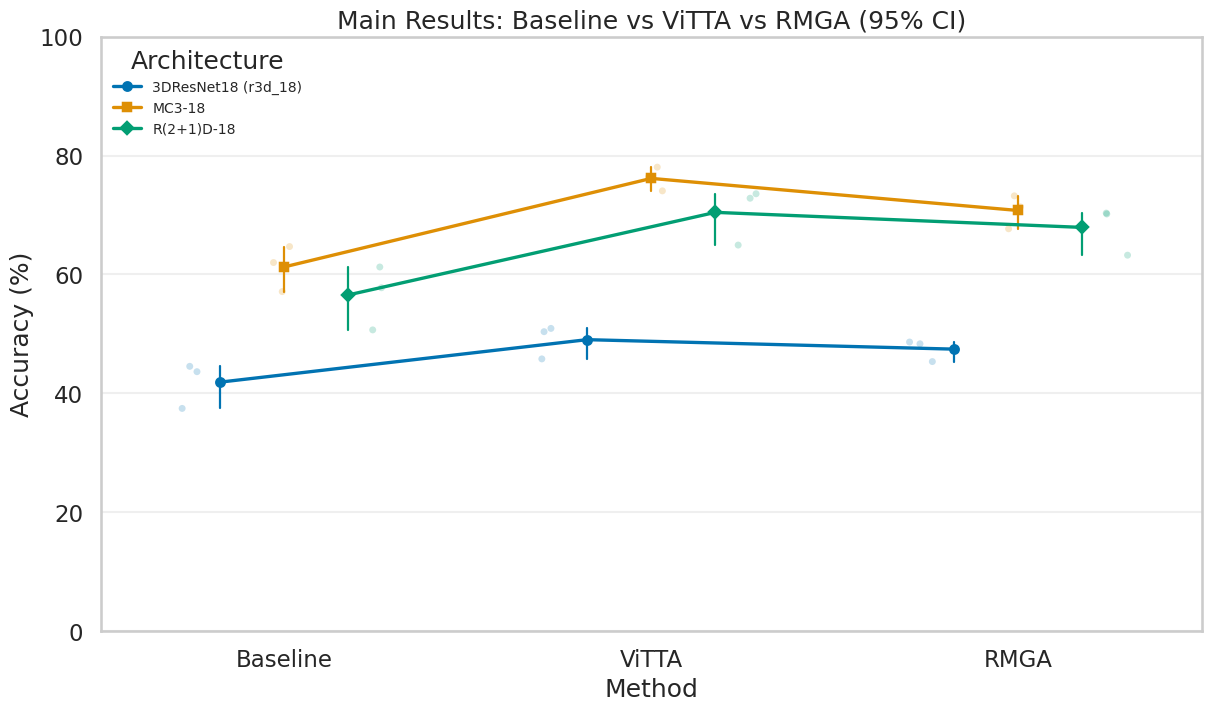

Saved: professional_figures_svg/professional_01_main_results_ci.svg


In [18]:
# Professional Figure 1: Main results with uncertainty-aware summary
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

sns.pointplot(
    data=paper_long,
    x="method",
    y="accuracy",
    hue="model_label",
    dodge=0.35,
    errorbar=("ci", 95),
    markers=["o", "s", "D"],
    linestyles="-",
    linewidth=2.4,
    err_kws={"linewidth": 1.6},
    ax=ax,
)

sns.stripplot(
    data=paper_long,
    x="method",
    y="accuracy",
    hue="model_label",
    dodge=True,
    alpha=0.22,
    size=5,
    linewidth=0,
    legend=False,
    ax=ax,
)

ax.set_title("Main Results: Baseline vs ViTTA vs RMGA (95% CI)")
ax.set_xlabel("Method")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.grid(True, axis="y", alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[: len(model_order_labels)], labels[: len(model_order_labels)], title="Architecture", loc="upper left", fontsize=10)

pro_f1 = PRO_OUT_DIR / "professional_01_main_results_ci.svg"
fig.savefig(pro_f1, format="svg", dpi=PRO_DPI, bbox_inches="tight")
pro_saved_files.append(str(pro_f1))
plt.show()
print(f"Saved: {pro_f1}")


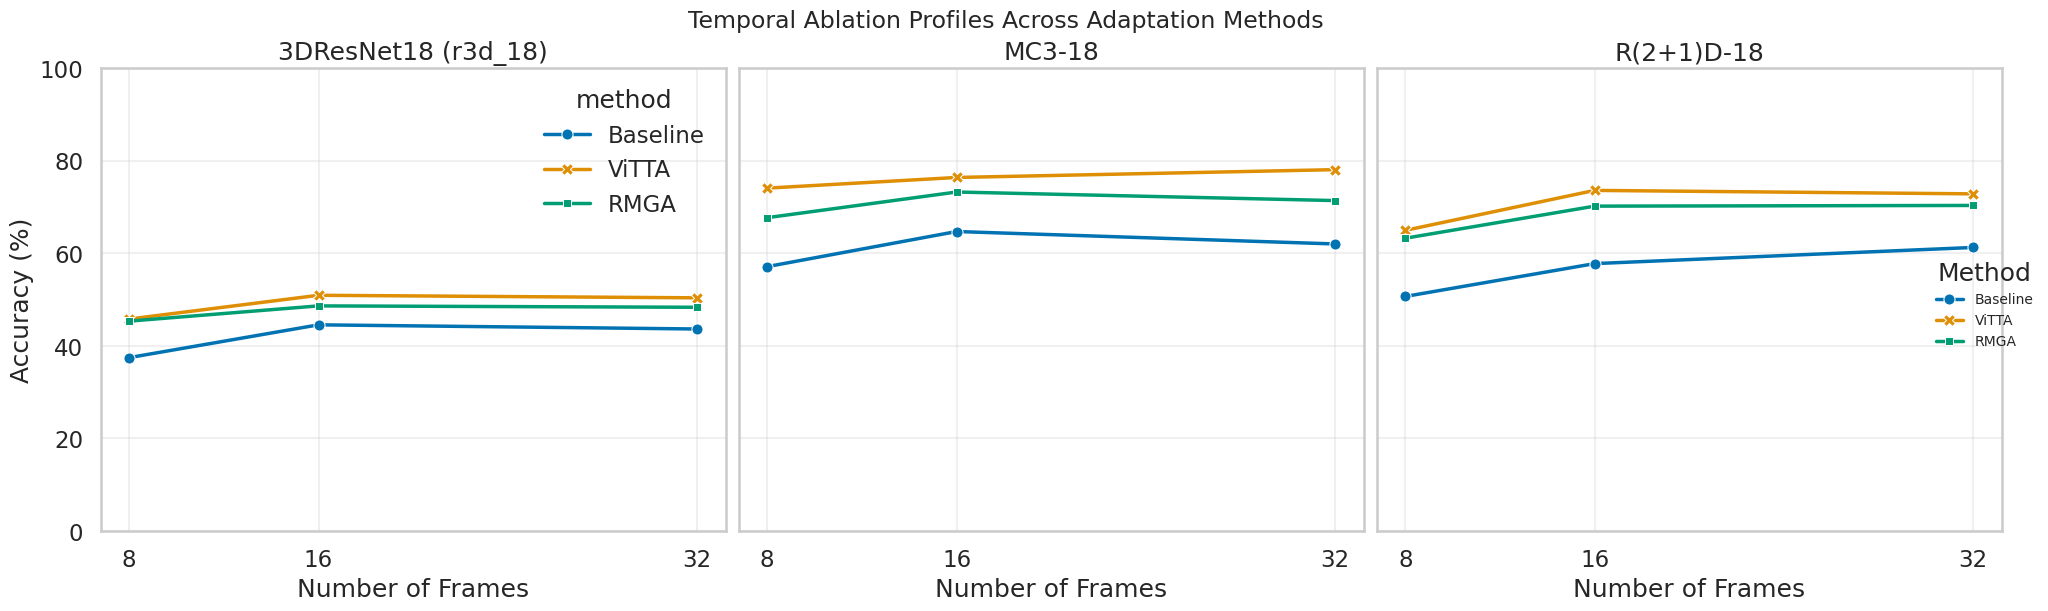

Saved: professional_figures_svg/professional_02_temporal_profiles_all_methods.svg


In [19]:
# Professional Figure 2: Temporal profiles for all methods by architecture
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True, constrained_layout=True)

for ax, model in zip(axes, MODEL_ORDER):
    sub = paper_long[paper_long["model"] == model].copy()
    sns.lineplot(
        data=sub,
        x="frames",
        y="accuracy",
        hue="method",
        style="method",
        markers=True,
        dashes=False,
        linewidth=2.5,
        markersize=8,
        estimator="mean",
        errorbar=None,
        ax=ax,
    )

    ax.set_title(MODEL_LABELS.get(model, model))
    ax.set_xlabel("Number of Frames")
    ax.set_xticks([8, 16, 32])
    ax.grid(True, alpha=0.28)

axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 100)

for i, ax in enumerate(axes):
    if i > 0:
        ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Method", loc="center right", bbox_to_anchor=(1.02, 0.5), fontsize=10)

fig.suptitle("Temporal Ablation Profiles Across Adaptation Methods", fontsize=17)

pro_f2 = PRO_OUT_DIR / "professional_02_temporal_profiles_all_methods.svg"
fig.savefig(pro_f2, format="svg", dpi=PRO_DPI, bbox_inches="tight")
pro_saved_files.append(str(pro_f2))
plt.show()
print(f"Saved: {pro_f2}")


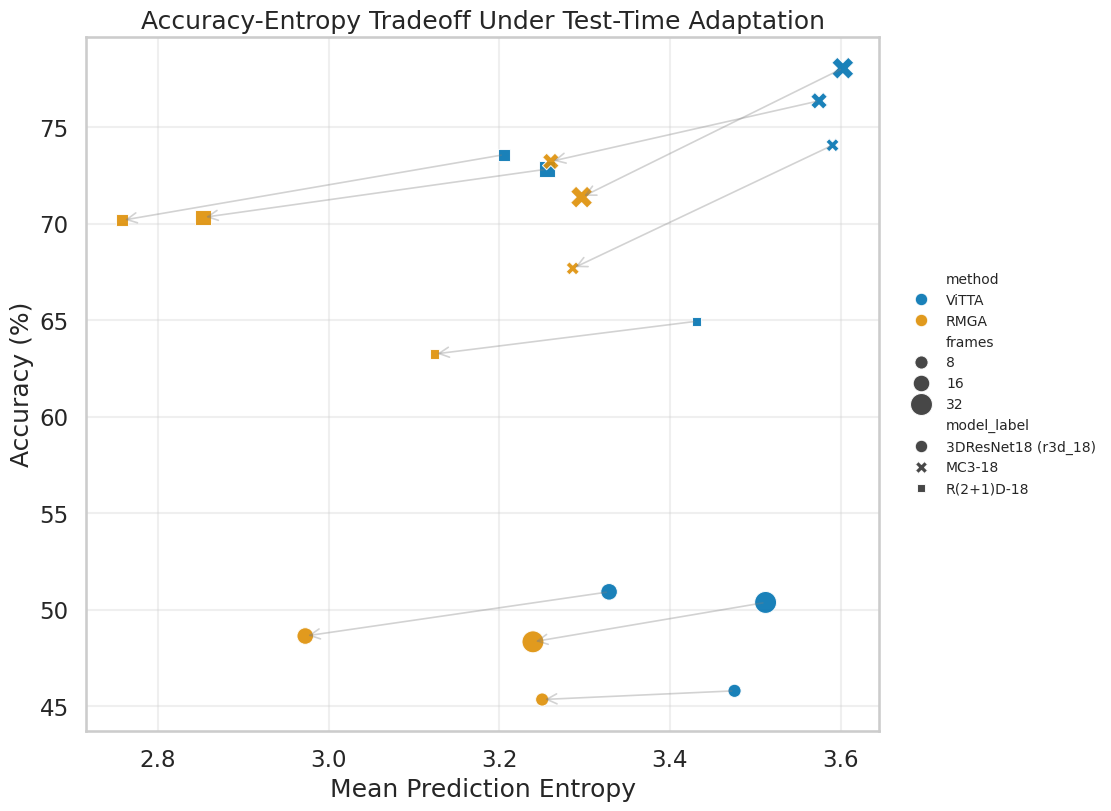

Saved: professional_figures_svg/professional_03_accuracy_entropy_tradeoff.svg


In [20]:
# Professional Figure 3: Accuracy-entropy tradeoff (ViTTA -> RMGA shift)
trade_v = summary_df[["exp_id", "model", "model_label", "frames", "vitta_acc", "vitta_entropy"]].copy()
trade_v = trade_v.rename(columns={"vitta_acc": "accuracy", "vitta_entropy": "entropy"})
trade_v["method"] = "ViTTA"

trade_r = summary_df[["exp_id", "model", "model_label", "frames", "rmga_acc", "rmga_entropy"]].copy()
trade_r = trade_r.rename(columns={"rmga_acc": "accuracy", "rmga_entropy": "entropy"})
trade_r["method"] = "RMGA"

trade_df = pd.concat([trade_v, trade_r], ignore_index=True)
trade_df["method"] = pd.Categorical(trade_df["method"], categories=["ViTTA", "RMGA"], ordered=True)

fig, ax = plt.subplots(figsize=(11, 8), constrained_layout=True)

# Draw arrows from ViTTA to RMGA for each experiment to show adaptation shift
for _, r in summary_df.iterrows():
    ax.annotate(
        "",
        xy=(r["rmga_entropy"], r["rmga_acc"]),
        xytext=(r["vitta_entropy"], r["vitta_acc"]),
        arrowprops={"arrowstyle": "->", "color": "gray", "alpha": 0.35, "lw": 1.2},
    )

sns.scatterplot(
    data=trade_df,
    x="entropy",
    y="accuracy",
    hue="method",
    style="model_label",
    size="frames",
    sizes=(90, 250),
    alpha=0.9,
    ax=ax,
)

ax.set_title("Accuracy-Entropy Tradeoff Under Test-Time Adaptation")
ax.set_xlabel("Mean Prediction Entropy")
ax.set_ylabel("Accuracy (%)")
ax.grid(True, alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=10)

pro_f3 = PRO_OUT_DIR / "professional_03_accuracy_entropy_tradeoff.svg"
fig.savefig(pro_f3, format="svg", dpi=PRO_DPI, bbox_inches="tight")
pro_saved_files.append(str(pro_f3))
plt.show()
print(f"Saved: {pro_f3}")


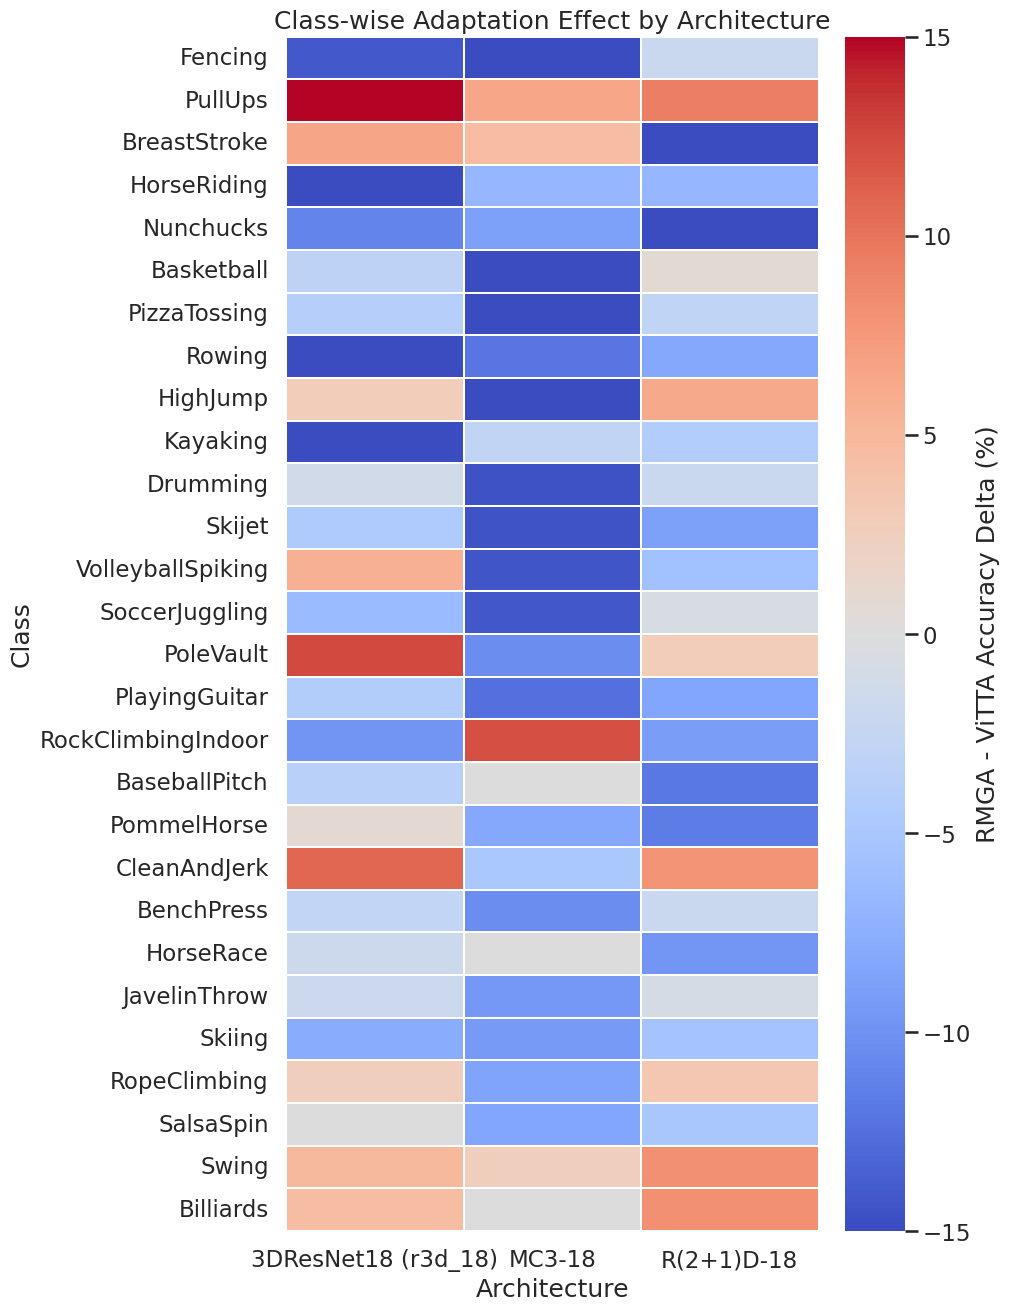

Saved: professional_figures_svg/professional_04_class_effect_heatmap_by_architecture.svg

Professional SVG exports:
 - professional_figures_svg/professional_01_main_results_ci.svg
 - professional_figures_svg/professional_02_temporal_profiles_all_methods.svg
 - professional_figures_svg/professional_03_accuracy_entropy_tradeoff.svg
 - professional_figures_svg/professional_04_class_effect_heatmap_by_architecture.svg


In [21]:
# Professional Figure 4: Class-level RMGA minus ViTTA effect by architecture
pc_v = perclass_vitta_df[["exp_id", "class_name", "acc_pct"]].rename(columns={"acc_pct": "vitta_acc"})
pc_r = perclass_rmga_df[["exp_id", "class_name", "acc_pct"]].rename(columns={"acc_pct": "rmga_acc"})

pc_delta = pc_r.merge(pc_v, on=["exp_id", "class_name"], how="inner")
pc_delta["delta"] = pc_delta["rmga_acc"] - pc_delta["vitta_acc"]
pc_delta = pc_delta.merge(summary_df[["exp_id", "model", "model_label"]], on="exp_id", how="left")

arch_delta = pc_delta.groupby(["class_name", "model_label"], as_index=False)["delta"].mean()
heat = arch_delta.pivot(index="class_name", columns="model_label", values="delta")
heat = heat.reindex(columns=model_order_labels)

# Keep top classes by absolute effect for readability in a paper figure
keep_classes = heat.abs().max(axis=1).sort_values(ascending=False).head(28).index
heat_show = heat.loc[keep_classes]

fig, ax = plt.subplots(figsize=(10, 13), constrained_layout=True)

sns.heatmap(
    heat_show,
    cmap="coolwarm",
    center=0,
    vmin=-15,
    vmax=15,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "RMGA - ViTTA Accuracy Delta (%)"},
    ax=ax,
)

ax.set_title("Class-wise Adaptation Effect by Architecture")
ax.set_xlabel("Architecture")
ax.set_ylabel("Class")

pro_f4 = PRO_OUT_DIR / "professional_04_class_effect_heatmap_by_architecture.svg"
fig.savefig(pro_f4, format="svg", dpi=PRO_DPI, bbox_inches="tight")
pro_saved_files.append(str(pro_f4))
plt.show()
print(f"Saved: {pro_f4}")

print("\nProfessional SVG exports:")
for p in pro_saved_files:
    print(" -", p)


## Proposed

This section follows the paper-facing plan in `proposed.md`.

Main outputs in this section:
- 7 figures aligned to the proposed paper figure list
- 4 main tables + 1 appendix table
- high-resolution SVG exports for figures (1200 DPI setting)
- CSV exports for tables

In [22]:
# Proposed: setup, metadata extraction, and table preparation
PROPOSED_OUT_DIR = LOG_DIR / "proposed_figures_svg"
PROPOSED_OUT_DIR.mkdir(parents=True, exist_ok=True)
PROPOSED_DPI = 1200

PROPOSED_TABLE_DIR = LOG_DIR / "proposed_tables"
PROPOSED_TABLE_DIR.mkdir(parents=True, exist_ok=True)


def proposed_extract_epoch_summaries(lines: list[str]) -> list[dict]:
    records: list[dict] = []
    summary_re = re.compile(r"Epoch\s+(\d+)\s+Summary", flags=re.IGNORECASE)
    train_re = re.compile(r"Train\s*.*Loss:\s*([0-9.]+)\s*\|\s*Acc:\s*([0-9.]+)%", flags=re.IGNORECASE)
    test_re = re.compile(r"Test\s*.*Loss:\s*([0-9.]+)\s*\|\s*Acc:\s*([0-9.]+)%", flags=re.IGNORECASE)

    for i, ln in enumerate(lines):
        m = summary_re.search(ln)
        if not m:
            continue

        epoch = int(m.group(1))
        train_loss = np.nan
        train_acc = np.nan
        test_loss = np.nan
        test_acc = np.nan

        for j in range(i + 1, min(i + 10, len(lines))):
            ln2 = lines[j]
            mt = train_re.search(ln2)
            if mt:
                train_loss = float(mt.group(1))
                train_acc = float(mt.group(2))
            ms = test_re.search(ln2)
            if ms:
                test_loss = float(ms.group(1))
                test_acc = float(ms.group(2))

        records.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "test_loss": test_loss,
                "test_acc": test_acc,
            }
        )

    return records


def proposed_parse_log_metadata(path: Path) -> dict:
    lines = path.read_text(encoding="utf-8", errors="ignore").splitlines()

    params = np.nan
    split = "70-30"
    vitta_on = False
    rmga_on = False
    stability = np.nan

    params_re = re.compile(r"\[MODEL\]\s+Total params:\s*([0-9,]+)")
    split_re = re.compile(r"Stratified\s+([0-9]+-[0-9]+)\s+split", flags=re.IGNORECASE)
    stability_re = re.compile(r"Stability Index.*:\s*([0-9]+(?:\.[0-9]+)?)")

    for ln in lines:
        mp = params_re.search(ln)
        if mp:
            params = int(mp.group(1).replace(",", ""))

        ms = split_re.search(ln)
        if ms:
            split = ms.group(1)

        if "[ViTTA] Running per-video adapted inference" in ln:
            vitta_on = True

        if "[RMGA] Running per-video Rhythmic Motion-Gated adaptation" in ln:
            rmga_on = True

        mst = stability_re.search(ln)
        if mst:
            stability = float(mst.group(1))

    epochs = proposed_extract_epoch_summaries(lines)
    if epochs:
        best_ep = max(epochs, key=lambda r: r["test_acc"] if pd.notna(r["test_acc"]) else -np.inf)
        best_epoch = int(best_ep["epoch"])
        best_train_loss = best_ep["train_loss"]
        best_test_loss = best_ep["test_loss"]
    else:
        best_epoch = np.nan
        best_train_loss = np.nan
        best_test_loss = np.nan

    return {
        "total_params": params,
        "split": split,
        "vitta_on": vitta_on,
        "rmga_on": rmga_on,
        "stability_index": stability,
        "best_epoch": best_epoch,
        "best_train_loss": best_train_loss,
        "best_test_loss": best_test_loss,
    }


def proposed_extract_class_distribution(lines: list[str]) -> pd.DataFrame:
    # train/test class counts are shared across runs; read first available block
    cls_re = re.compile(r"^\s*([A-Za-z0-9_]+)\s+train=\s*(\d+)\s*\|\s*test=\s*(\d+)")
    rows = []
    for ln in lines:
        m = cls_re.match(ln)
        if m:
            rows.append(
                {
                    "class_name": m.group(1),
                    "train_count": int(m.group(2)),
                    "test_count": int(m.group(3)),
                }
            )
    return pd.DataFrame(rows)


proposed_meta_rows = []
for _, row in summary_df.iterrows():
    path = LOG_DIR / row["file_name"]
    meta = proposed_parse_log_metadata(path)
    proposed_meta_rows.append({"exp_id": row["exp_id"], **meta})

proposed_meta_df = pd.DataFrame(proposed_meta_rows)

# Class distribution from first file containing train/test-class block
proposed_class_dist_df = pd.DataFrame()
for p in LOG_FILES:
    lines = p.read_text(encoding="utf-8", errors="ignore").splitlines()
    candidate = proposed_extract_class_distribution(lines)
    if not candidate.empty:
        proposed_class_dist_df = candidate.sort_values("class_name").reset_index(drop=True)
        break

proposed_df = summary_df.merge(proposed_meta_df, on="exp_id", how="left")

# Main tables
setup_table = proposed_df[
    [
        "short_label",
        "model_label",
        "frames",
        "batch_size",
        "epochs",
        "total_params",
        "split",
        "vitta_on",
        "rmga_on",
    ]
].copy()
setup_table = setup_table.rename(
    columns={
        "short_label": "run_id",
        "model_label": "architecture",
        "batch_size": "batch",
        "total_params": "trainable_params",
        "split": "train_test_split",
    }
)

setup_table["trainable_params"] = setup_table["trainable_params"].apply(
    lambda x: f"{int(x):,}" if pd.notna(x) else "NA"
)

main_results_table = proposed_df[
    [
        "short_label",
        "model_label",
        "frames",
        "batch_size",
        "best_train_loss",
        "best_test_loss",
        "best_test_acc",
        "vitta_acc",
        "rmga_acc",
        "best_epoch",
    ]
].copy()
main_results_table = main_results_table.rename(
    columns={
        "short_label": "run_id",
        "model_label": "architecture",
        "batch_size": "batch",
        "best_test_acc": "baseline_acc",
    }
)
main_results_table["best_adapted_acc"] = main_results_table[["vitta_acc", "rmga_acc"]].max(axis=1)
main_results_table["best_adapted_method"] = np.where(
    main_results_table["vitta_acc"] >= main_results_table["rmga_acc"], "ViTTA", "RMGA"
)

frame_ablation_table = (
    proposed_df.pivot_table(index="model_label", columns="frames", values="best_test_acc", aggfunc="mean")
    .reindex(model_order_labels)
)
frame_ablation_table = frame_ablation_table.rename(columns={8: "8_frames", 16: "16_frames", 32: "32_frames"})
frame_ablation_table["best_setting"] = frame_ablation_table[[c for c in ["8_frames", "16_frames", "32_frames"] if c in frame_ablation_table.columns]].idxmax(axis=1)

adaptation_metrics_table = pd.DataFrame(
    {
        "method": ["Baseline", "ViTTA", "RMGA"],
        "accuracy": [
            proposed_df["best_test_acc"].mean(),
            proposed_df["vitta_acc"].mean(),
            proposed_df["rmga_acc"].mean(),
        ],
        "mean_entropy": [
            np.nan,
            proposed_df["vitta_entropy"].mean(),
            proposed_df["rmga_entropy"].mean(),
        ],
        "mean_confidence": [
            np.nan,
            np.nan,
            proposed_df["rmga_conf"].mean(),
        ],
        "stability_index": [
            np.nan,
            np.nan,
            proposed_df["stability_index"].mean(),
        ],
    }
)

# Appendix table
vitta_mean_cls = perclass_vitta_df.groupby("class_name", as_index=False)["acc_pct"].mean().rename(columns={"acc_pct": "vitta_acc"})
rmga_mean_cls = perclass_rmga_df.groupby("class_name", as_index=False)["acc_pct"].mean().rename(columns={"acc_pct": "rmga_acc"})
appendix_per_class_table = vitta_mean_cls.merge(rmga_mean_cls, on="class_name", how="outer")
appendix_per_class_table["delta"] = appendix_per_class_table["rmga_acc"] - appendix_per_class_table["vitta_acc"]
if not proposed_class_dist_df.empty:
    appendix_per_class_table = appendix_per_class_table.merge(
        proposed_class_dist_df[["class_name", "test_count"]].rename(columns={"test_count": "support"}),
        on="class_name",
        how="left",
    )

appendix_per_class_table = appendix_per_class_table.sort_values("delta", ascending=False).reset_index(drop=True)

# Save tables as CSV
setup_table.to_csv(PROPOSED_TABLE_DIR / "main_experimental_setup.csv", index=False)
main_results_table.to_csv(PROPOSED_TABLE_DIR / "main_results.csv", index=False)
frame_ablation_table.reset_index().rename(columns={"model_label": "architecture"}).to_csv(
    PROPOSED_TABLE_DIR / "main_frame_ablation.csv", index=False
)
adaptation_metrics_table.to_csv(PROPOSED_TABLE_DIR / "main_adaptation_metrics.csv", index=False)
appendix_per_class_table.to_csv(PROPOSED_TABLE_DIR / "appendix_per_class_accuracy.csv", index=False)

print("Proposed section ready")
print(" - figure folder:", PROPOSED_OUT_DIR)
print(" - table folder :", PROPOSED_TABLE_DIR)
print(" - class rows   :", len(proposed_class_dist_df))
print(" - runs         :", len(proposed_df))


Proposed section ready
 - figure folder: proposed_figures_svg
 - table folder : proposed_tables
 - class rows   : 50
 - runs         : 9


In [23]:
# Proposed tables preview (main paper + appendix)
print("Main Table 1: Experimental setup")
display(setup_table)

print("Main Table 2: Main results")
display(main_results_table.round(3))

print("Main Table 3: Frame ablation")
display(frame_ablation_table.round(3))

print("Main Table 4: Adaptation metrics")
display(adaptation_metrics_table.round(3))

print("Appendix Table: Per-class accuracy (top 20 by delta)")
display(appendix_per_class_table.head(20).round(3))


Main Table 1: Experimental setup


,run_id,architecture,frames,batch,epochs,trainable_params,train_test_split,vitta_on,rmga_on
0,r3d_18-F8-B40-E1,3DResNet18 (r3d_18),8,40,1,"33,191,922",70-30,True,True
1,r3d_18-F16-B24-E1,3DResNet18 (r3d_18),16,24,1,"33,191,922",70-30,True,True
2,r3d_18-F32-B40-E1,3DResNet18 (r3d_18),32,40,1,"33,191,922",70-30,True,True
3,mc3_18-F8-B40-E2,MC3-18,8,40,2,"11,515,890",70-30,True,True
4,mc3_18-F16-B24-E2,MC3-18,16,24,2,"11,515,890",70-30,True,True
5,mc3_18-F32-B40-E2,MC3-18,32,40,2,"11,515,890",70-30,True,True
6,r2plus1d_18-F8-B40-E2,R(2+1)D-18,8,40,2,"31,325,775",70-30,True,True
7,r2plus1d_18-F16-B24-E2,R(2+1)D-18,16,24,2,"31,325,775",70-30,True,True
8,r2plus1d_18-F32-B40-E2,R(2+1)D-18,32,40,2,"31,325,775",70-30,True,True


Main Table 2: Main results


,run_id,architecture,frames,batch,best_train_loss,best_test_loss,baseline_acc,vitta_acc,rmga_acc,best_epoch,best_adapted_acc,best_adapted_method
0,r3d_18-F8-B40-E1,3DResNet18 (r3d_18),8,40,2.328,2.780,37.46,45.79,45.34,1,45.79,ViTTA
1,r3d_18-F16-B24-E1,3DResNet18 (r3d_18),16,24,1.880,2.461,44.54,50.92,48.63,1,50.92,ViTTA
2,r3d_18-F32-B40-E1,3DResNet18 (r3d_18),32,40,2.027,2.496,43.64,50.37,48.33,1,50.37,ViTTA
3,mc3_18-F8-B40-E2,MC3-18,8,40,1.090,2.249,57.11,74.06,67.68,2,74.06,ViTTA
4,mc3_18-F16-B24-E2,MC3-18,16,24,1.986,2.108,64.69,76.36,73.22,1,76.36,ViTTA
5,mc3_18-F32-B40-E2,MC3-18,32,40,1.051,2.117,62.00,78.05,71.37,2,78.05,ViTTA
6,r2plus1d_18-F8-B40-E2,R(2+1)D-18,8,40,2.149,2.446,50.67,64.94,63.24,1,64.94,ViTTA
7,r2plus1d_18-F16-B24-E2,R(2+1)D-18,16,24,0.867,2.112,57.76,73.57,70.17,2,73.57,ViTTA
8,r2plus1d_18-F32-B40-E2,R(2+1)D-18,32,40,0.852,2.009,61.25,72.82,70.32,2,72.82,ViTTA


Main Table 3: Frame ablation


frames,8_frames,16_frames,32_frames,best_setting
model_label,,,,
3DResNet18 (r3d_18),37.46,44.54,43.64,16_frames
MC3-18,57.11,64.69,62.00,16_frames
R(2+1)D-18,50.67,57.76,61.25,32_frames


Main Table 4: Adaptation metrics


,method,accuracy,mean_entropy,mean_confidence,stability_index
0,Baseline,53.236,NaN,NaN,NaN
1,ViTTA,65.209,3.442,NaN,NaN
2,RMGA,62.033,3.116,0.272,22.373


Appendix Table: Per-class accuracy (top 20 by delta)


,class_name,vitta_acc,rmga_acc,delta,support
0,PullUps,59.578,73.144,13.567,36
1,Swing,88.878,94.044,5.167,41
2,CleanAndJerk,38.544,43.144,4.600,34
3,Billiards,80.011,84.200,4.189,45
4,MilitaryParade,95.622,97.967,2.344,38
5,Lunges,34.389,36.244,1.856,42
6,PoleVault,53.933,55.556,1.622,48
7,JumpRope,63.700,64.933,1.233,45
8,YoYo,64.033,65.211,1.178,38
9,HulaHoop,44.156,45.011,0.856,38


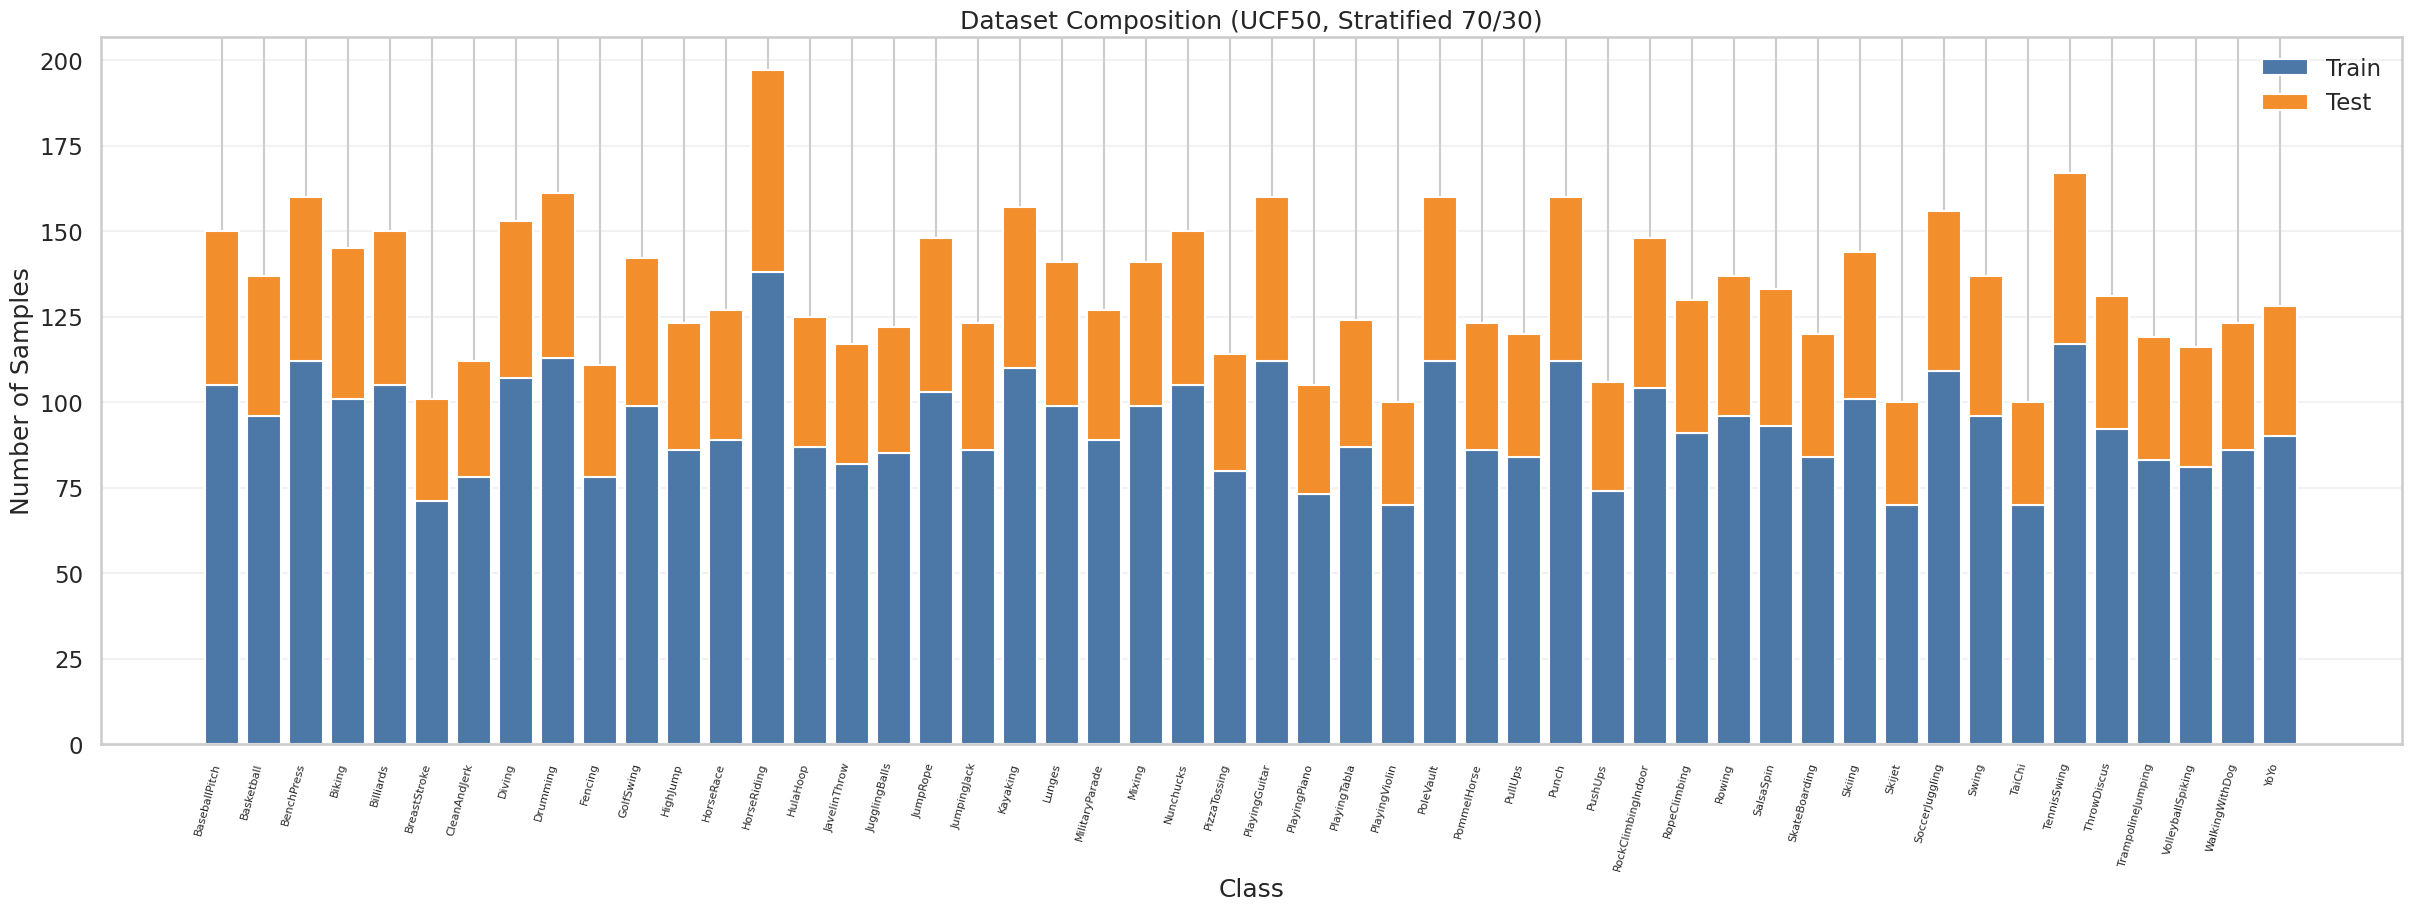

Saved: proposed_figures_svg/proposed_01_dataset_composition_stacked.svg


In [24]:
# Proposed Figure 1: Dataset composition (stacked train/test counts by class)
fig, ax = plt.subplots(figsize=(24, 9), constrained_layout=True)

if proposed_class_dist_df.empty:
    print("No class distribution block found in logs; figure skipped.")
else:
    cls = proposed_class_dist_df.sort_values("class_name")
    x = np.arange(len(cls))

    ax.bar(x, cls["train_count"], label="Train", color="#4C78A8")
    ax.bar(x, cls["test_count"], bottom=cls["train_count"], label="Test", color="#F28E2B")

    ax.set_title("Dataset Composition (UCF50, Stratified 70/30)")
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of Samples")
    ax.set_xticks(x)
    ax.set_xticklabels(cls["class_name"], rotation=75, ha="right", fontsize=8)
    ax.legend(loc="upper right")
    ax.grid(True, axis="y", alpha=0.25)

    p1 = PROPOSED_OUT_DIR / "proposed_01_dataset_composition_stacked.svg"
    fig.savefig(p1, format="svg", dpi=PROPOSED_DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {p1}")


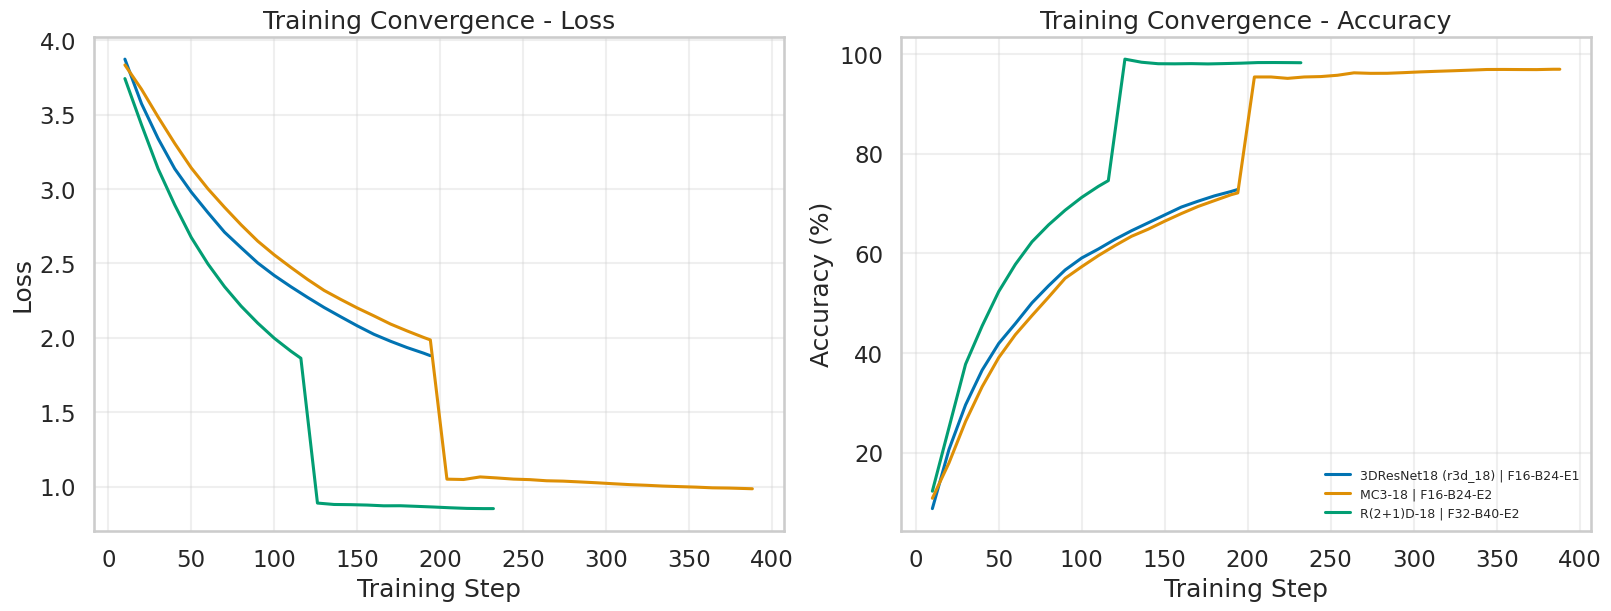

Saved: proposed_figures_svg/proposed_02_training_convergence.svg


In [25]:
# Proposed Figure 2: Training convergence (representative run per architecture)
prop_rep_idx = proposed_df.groupby("model")["best_test_acc"].idxmax()
prop_rep_df = proposed_df.loc[prop_rep_idx].sort_values("model_sort")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

for _, r in prop_rep_df.iterrows():
    tr = train_curve_df[train_curve_df["exp_id"] == r["exp_id"]].sort_values("global_step")
    if tr.empty:
        continue

    lbl = f"{r['model_label']} | F{int(r['frames'])}-B{int(r['batch_size'])}-E{int(r['epochs'])}"
    axes[0].plot(tr["global_step"], tr["loss"], linewidth=2.2, label=lbl)
    axes[1].plot(tr["global_step"], tr["acc_pct"], linewidth=2.2, label=lbl)

axes[0].set_title("Training Convergence - Loss")
axes[0].set_xlabel("Training Step")
axes[0].set_ylabel("Loss")

axes[1].set_title("Training Convergence - Accuracy")
axes[1].set_xlabel("Training Step")
axes[1].set_ylabel("Accuracy (%)")

for ax in axes:
    ax.grid(True, alpha=0.3)

axes[1].legend(loc="lower right", fontsize=9)

p2 = PROPOSED_OUT_DIR / "proposed_02_training_convergence.svg"
fig.savefig(p2, format="svg", dpi=PROPOSED_DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {p2}")


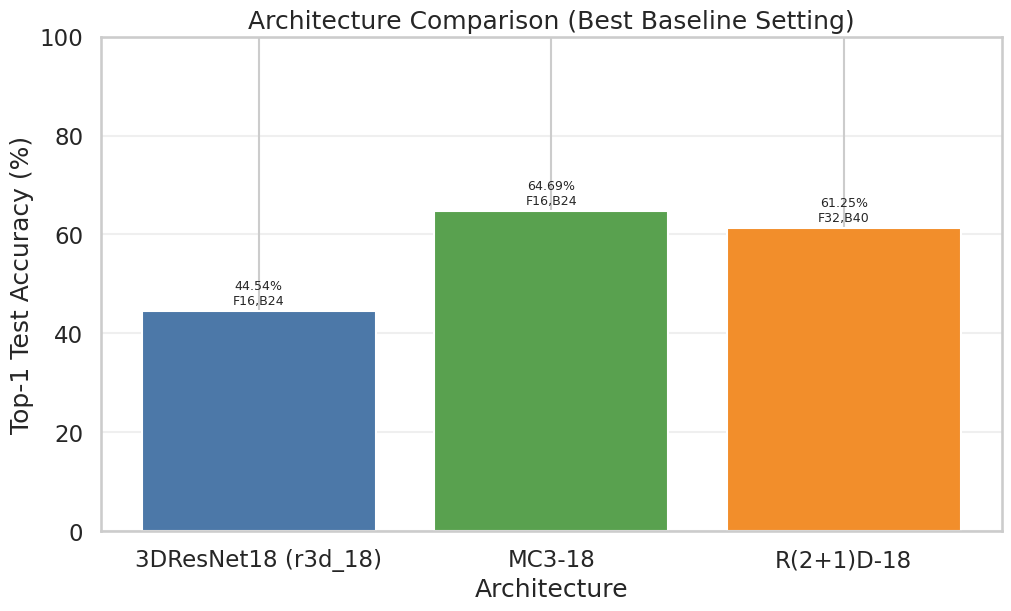

Saved: proposed_figures_svg/proposed_03_architecture_comparison_best_settings.svg


In [26]:
# Proposed Figure 3: Architecture comparison (best setting per architecture)
arch_best = proposed_df.loc[proposed_df.groupby("model")["best_test_acc"].idxmax()].sort_values("model_sort")

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

bars = ax.bar(arch_best["model_label"], arch_best["best_test_acc"], color=["#4C78A8", "#59A14F", "#F28E2B"])
for b, (_, r) in zip(bars, arch_best.iterrows()):
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.7,
        f"{r['best_test_acc']:.2f}%\nF{int(r['frames'])},B{int(r['batch_size'])}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title("Architecture Comparison (Best Baseline Setting)")
ax.set_xlabel("Architecture")
ax.set_ylabel("Top-1 Test Accuracy (%)")
ax.set_ylim(0, 100)
ax.grid(True, axis="y", alpha=0.3)

p3 = PROPOSED_OUT_DIR / "proposed_03_architecture_comparison_best_settings.svg"
fig.savefig(p3, format="svg", dpi=PROPOSED_DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {p3}")


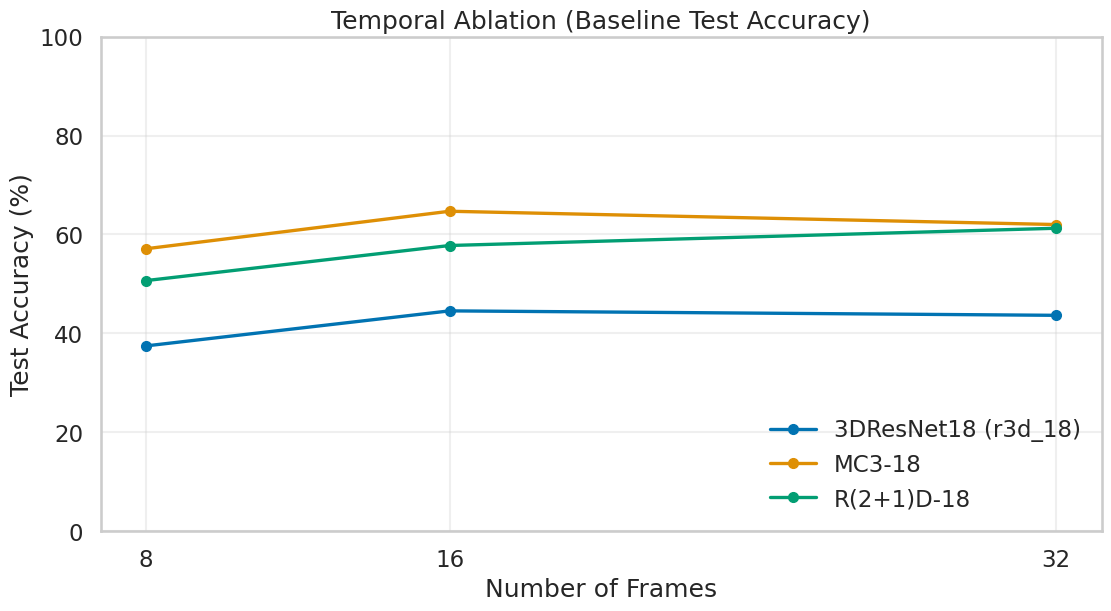

Saved: proposed_figures_svg/proposed_04_temporal_ablation.svg


In [27]:
# Proposed Figure 4: Temporal ablation (frames vs baseline test accuracy)
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)

for model in MODEL_ORDER:
    sub = proposed_df[proposed_df["model"] == model].sort_values("frames")
    ax.plot(
        sub["frames"],
        sub["best_test_acc"],
        marker="o",
        linewidth=2.4,
        markersize=7,
        label=MODEL_LABELS.get(model, model),
    )

ax.set_title("Temporal Ablation (Baseline Test Accuracy)")
ax.set_xlabel("Number of Frames")
ax.set_ylabel("Test Accuracy (%)")
ax.set_xticks([8, 16, 32])
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")

p4 = PROPOSED_OUT_DIR / "proposed_04_temporal_ablation.svg"
fig.savefig(p4, format="svg", dpi=PROPOSED_DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {p4}")


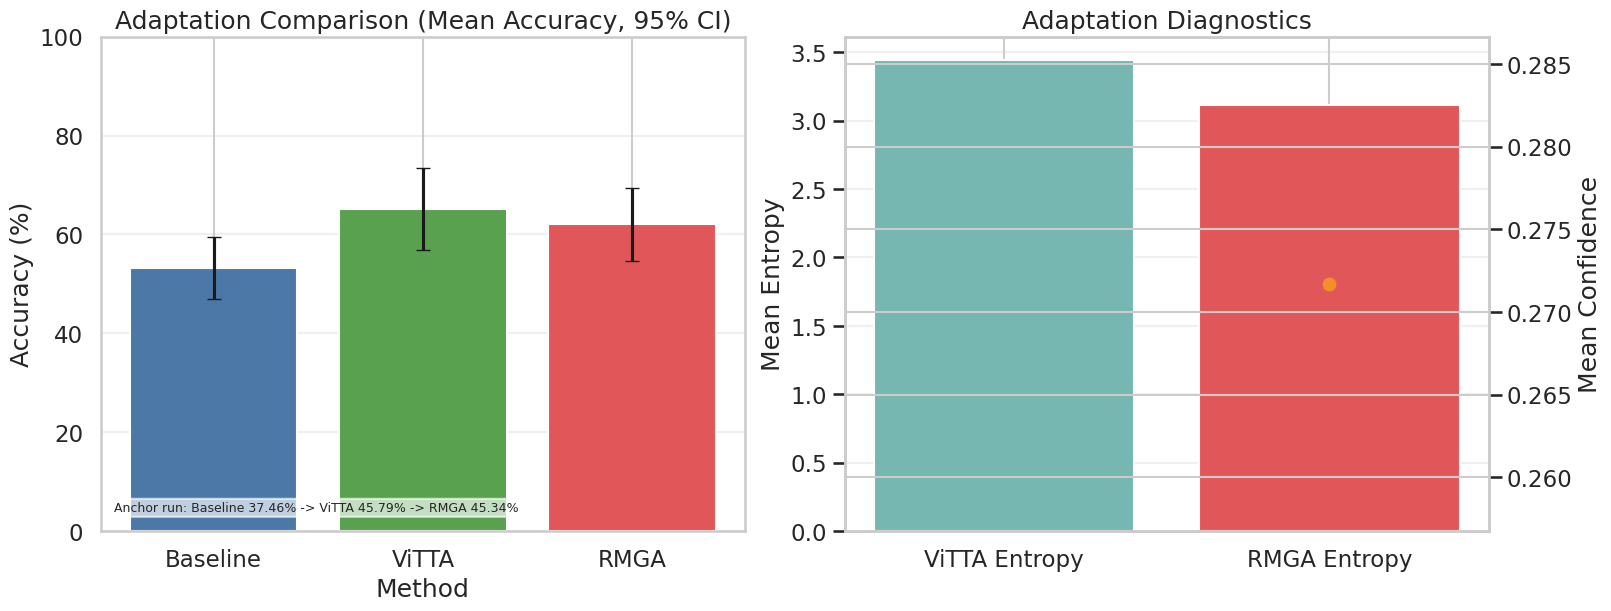

Saved: proposed_figures_svg/proposed_05_adaptation_comparison.svg


In [28]:
# Proposed Figure 5: Adaptation comparison (accuracy + entropy/confidence)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

method_values = {
    "Baseline": proposed_df["best_test_acc"].dropna().values,
    "ViTTA": proposed_df["vitta_acc"].dropna().values,
    "RMGA": proposed_df["rmga_acc"].dropna().values,
}
methods = list(method_values.keys())
means = np.array([np.mean(method_values[m]) for m in methods])
stds = np.array([np.std(method_values[m], ddof=1) if len(method_values[m]) > 1 else 0 for m in methods])
cis = 1.96 * stds / np.sqrt([len(method_values[m]) for m in methods])

axes[0].bar(methods, means, yerr=cis, color=["#4C78A8", "#59A14F", "#E15759"], capsize=5)
axes[0].set_title("Adaptation Comparison (Mean Accuracy, 95% CI)")
axes[0].set_xlabel("Method")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 100)
axes[0].grid(True, axis="y", alpha=0.3)

# Optional diagnostic panel
entropy_means = [proposed_df["vitta_entropy"].mean(), proposed_df["rmga_entropy"].mean()]
axes[1].bar(["ViTTA Entropy", "RMGA Entropy"], entropy_means, color=["#76B7B2", "#E15759"])
axes[1].set_ylabel("Mean Entropy")
axes[1].set_title("Adaptation Diagnostics")
axes[1].grid(True, axis="y", alpha=0.3)

ax2 = axes[1].twinx()
ax2.plot([0, 1], [np.nan, proposed_df["rmga_conf"].mean()], color="#F28E2B", marker="o", linewidth=2.2)
ax2.set_ylabel("Mean Confidence")

# Anchor run annotation requested in proposed.md narrative
anchor = proposed_df[
    (proposed_df["model"] == "r3d_18")
    & (proposed_df["frames"] == 8)
    & (proposed_df["batch_size"] == 40)
    & (proposed_df["epochs"] == 1)
]
if not anchor.empty:
    a = anchor.iloc[0]
    axes[0].text(
        0.02,
        0.04,
        f"Anchor run: Baseline {a['best_test_acc']:.2f}% -> ViTTA {a['vitta_acc']:.2f}% -> RMGA {a['rmga_acc']:.2f}%",
        transform=axes[0].transAxes,
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.2", "facecolor": "white", "alpha": 0.65},
    )

p5 = PROPOSED_OUT_DIR / "proposed_05_adaptation_comparison.svg"
fig.savefig(p5, format="svg", dpi=PROPOSED_DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {p5}")


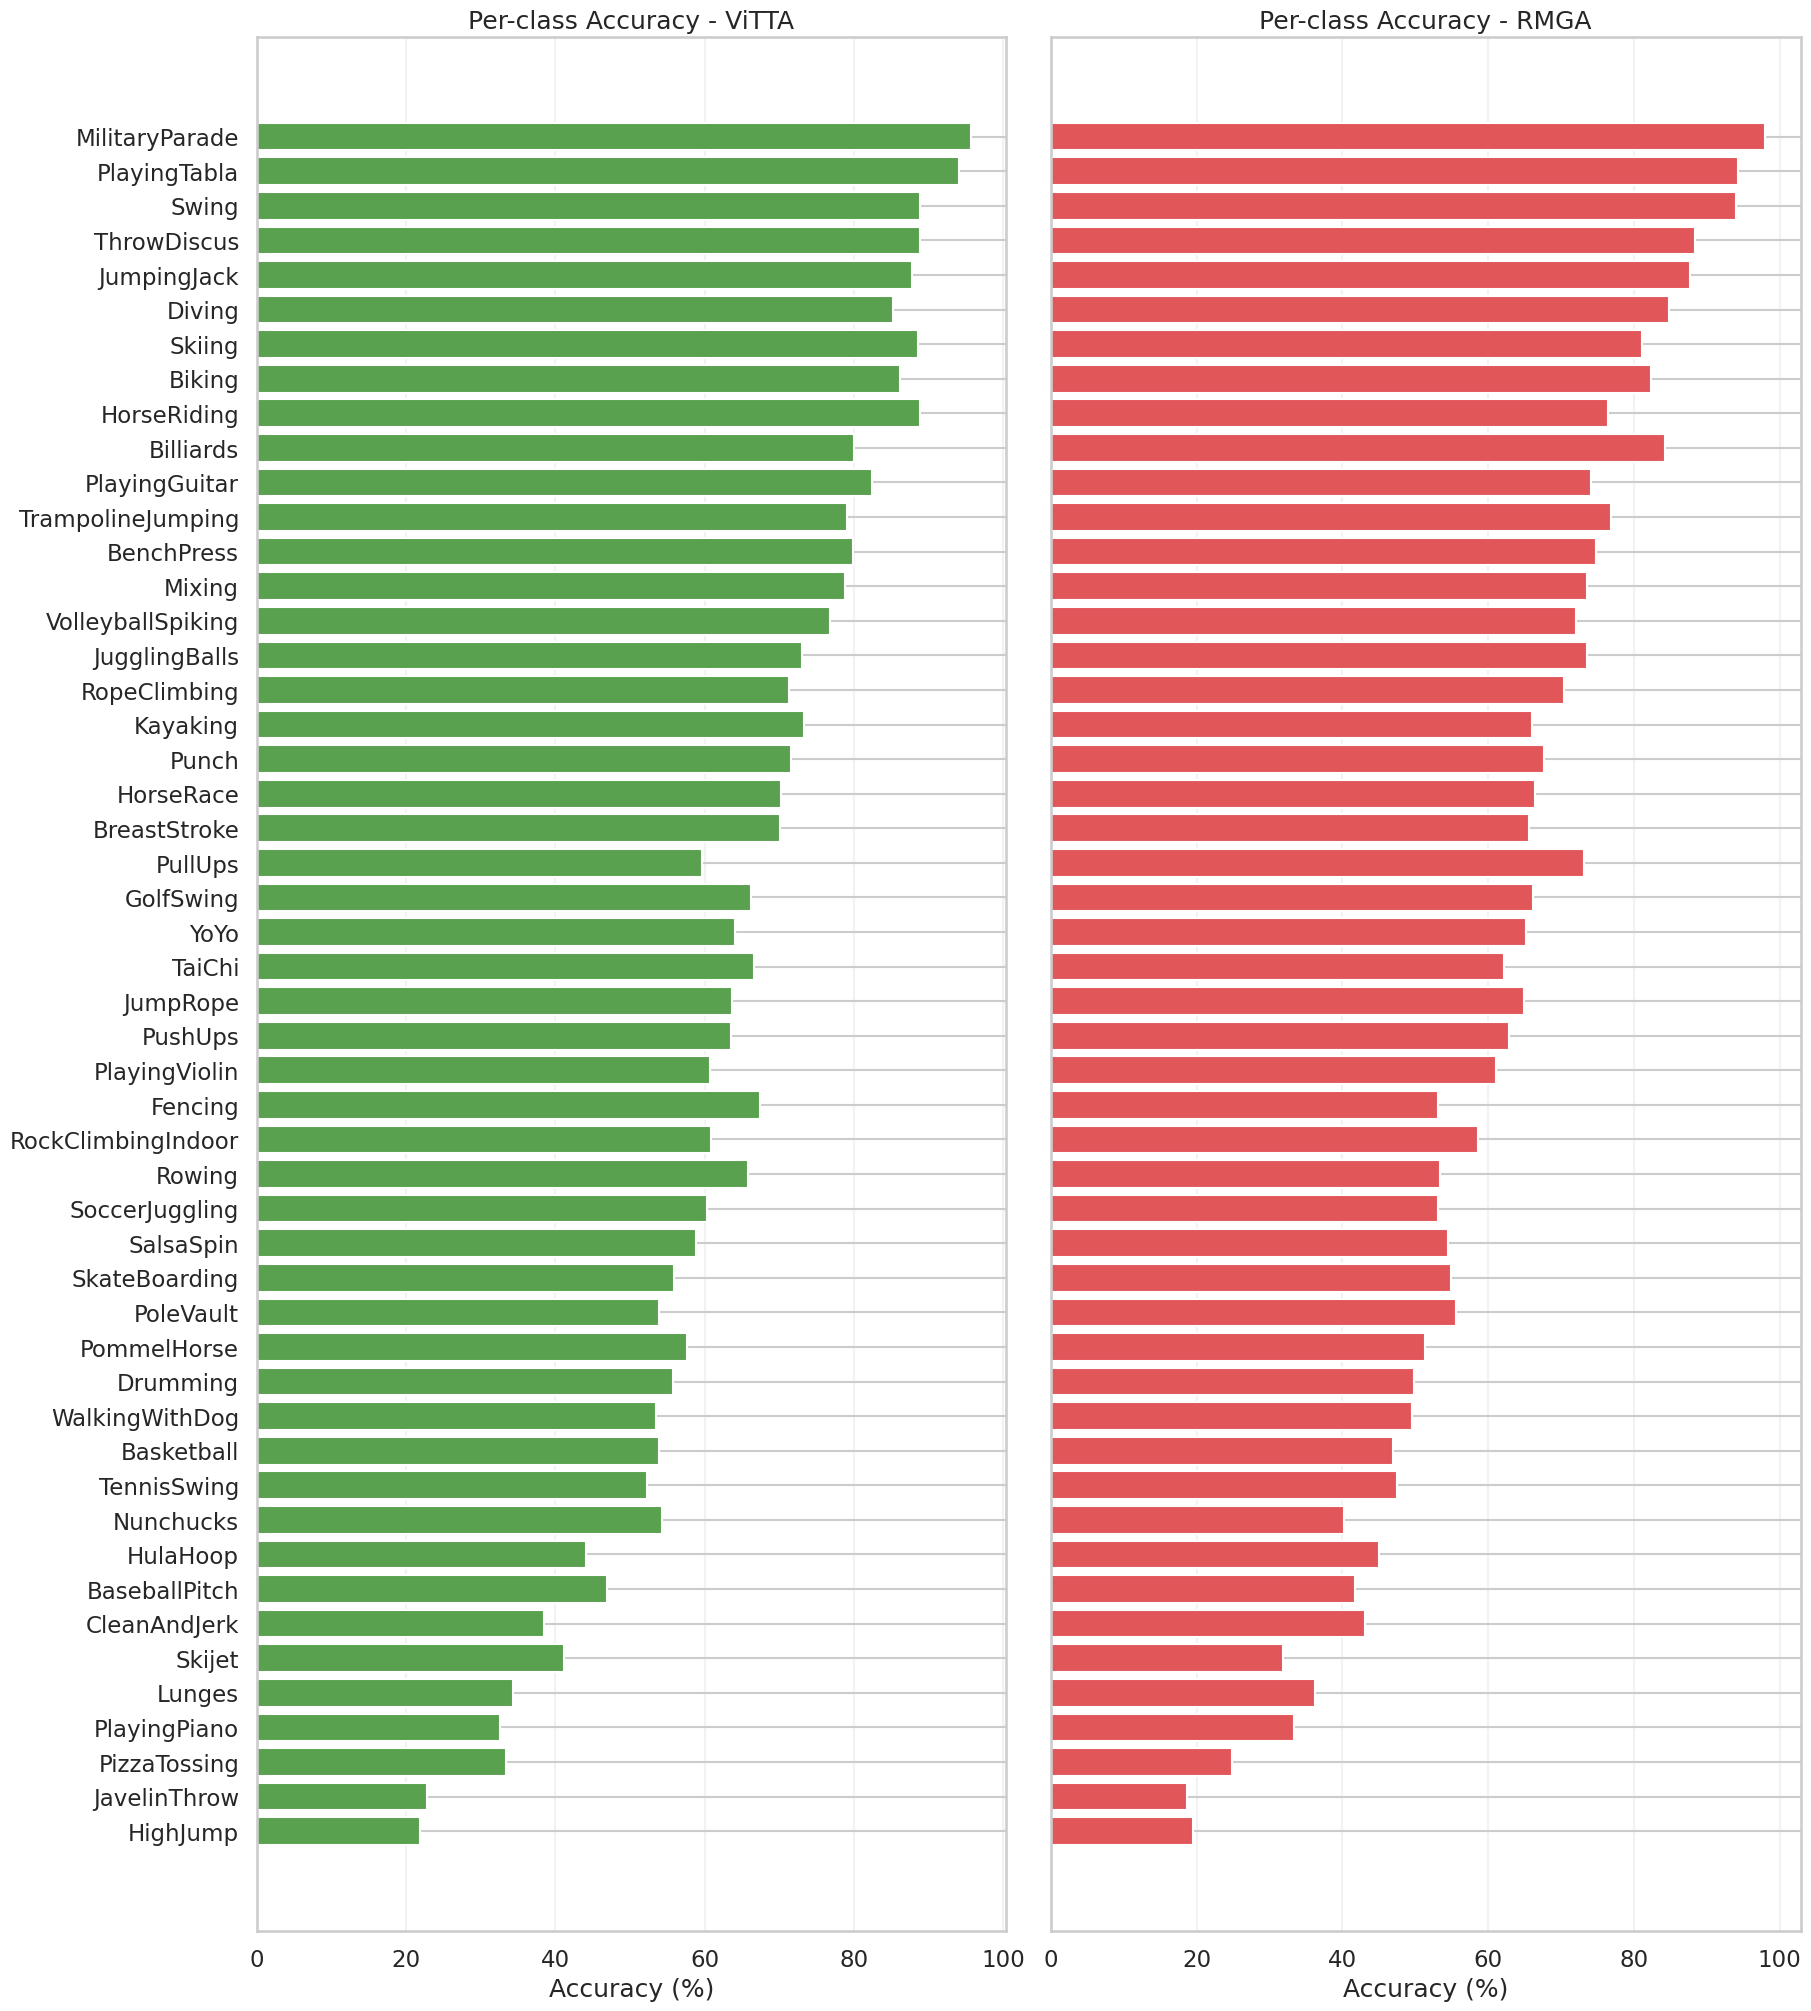

Saved: proposed_figures_svg/proposed_06_per_class_performance.svg


In [29]:
# Proposed Figure 6: Per-class performance (ViTTA and RMGA)
per_class_perf = appendix_per_class_table[["class_name", "vitta_acc", "rmga_acc", "delta"]].copy()
per_class_perf["avg"] = per_class_perf[["vitta_acc", "rmga_acc"]].mean(axis=1)
per_class_perf = per_class_perf.sort_values("avg", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 20), sharey=True, constrained_layout=True)

axes[0].barh(per_class_perf["class_name"], per_class_perf["vitta_acc"], color="#59A14F")
axes[0].set_title("Per-class Accuracy - ViTTA")
axes[0].set_xlabel("Accuracy (%)")
axes[0].grid(True, axis="x", alpha=0.25)

axes[1].barh(per_class_perf["class_name"], per_class_perf["rmga_acc"], color="#E15759")
axes[1].set_title("Per-class Accuracy - RMGA")
axes[1].set_xlabel("Accuracy (%)")
axes[1].grid(True, axis="x", alpha=0.25)

p6 = PROPOSED_OUT_DIR / "proposed_06_per_class_performance.svg"
fig.savefig(p6, format="svg", dpi=PROPOSED_DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {p6}")


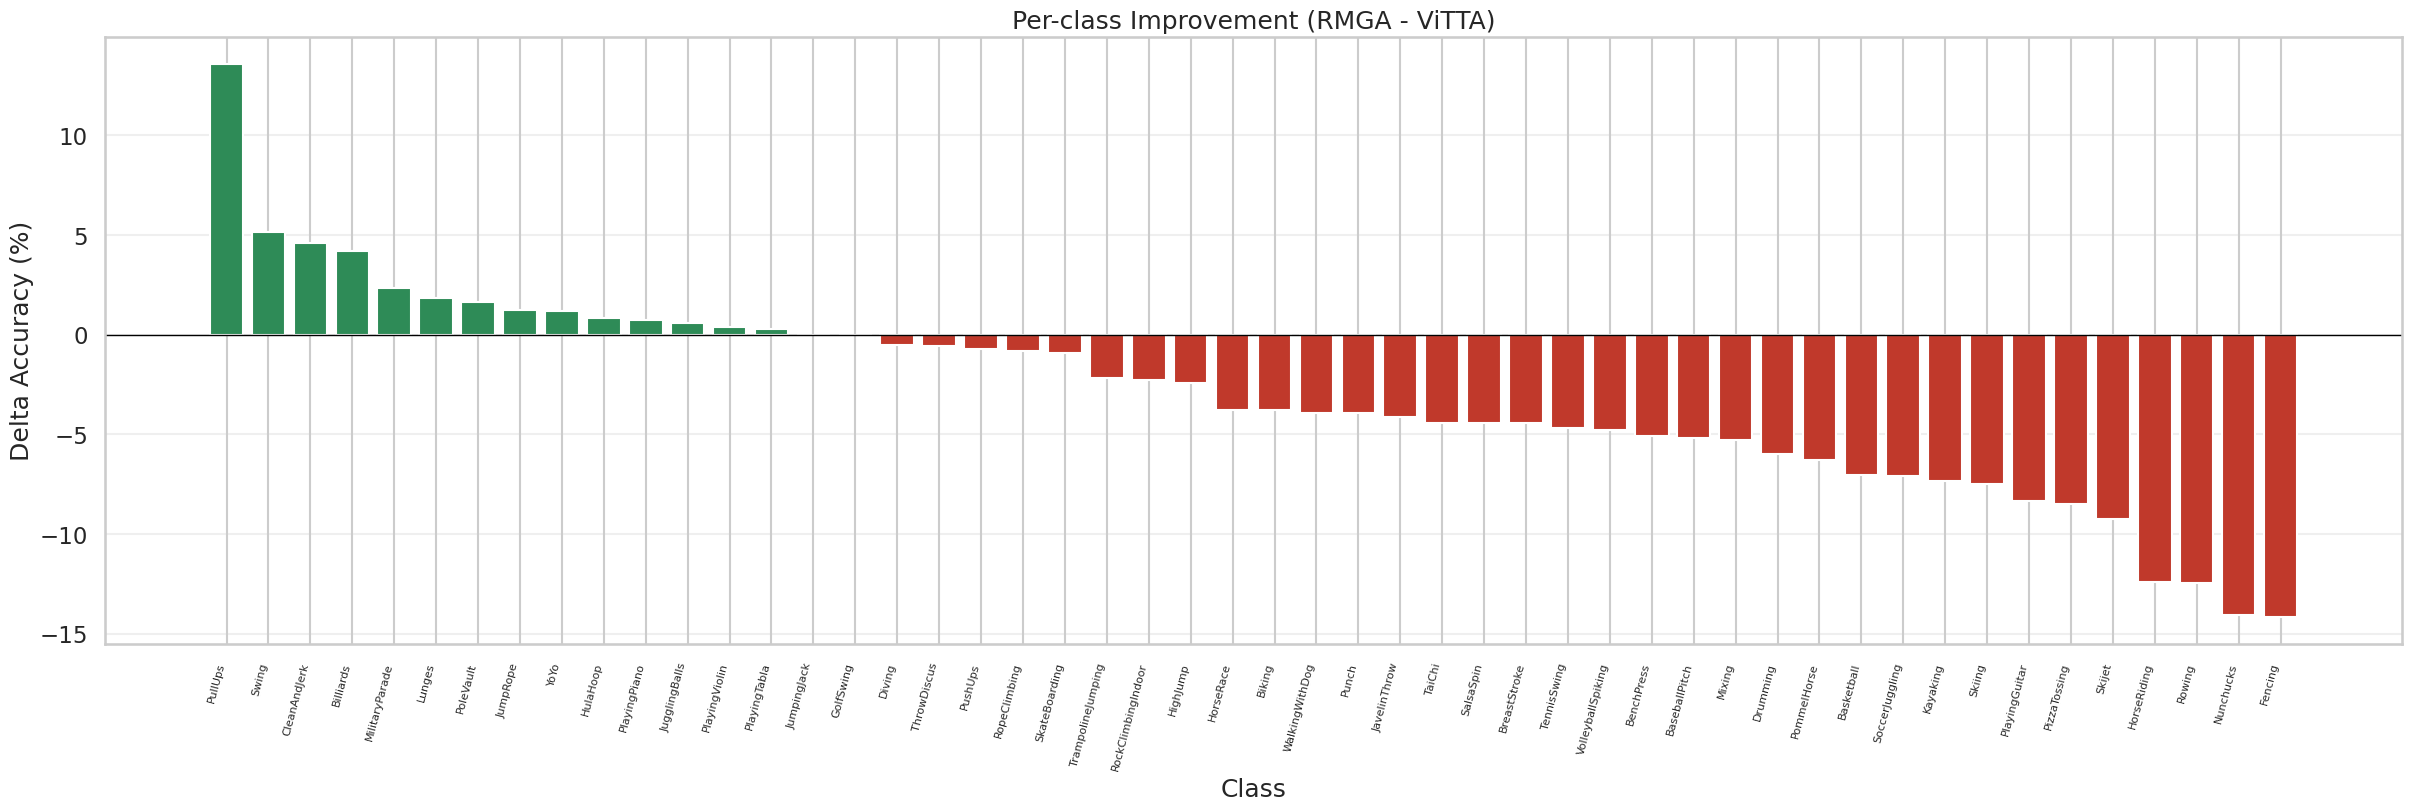

Saved: proposed_figures_svg/proposed_07_per_class_improvement_delta.svg

Proposed figure exports:
 - proposed_figures_svg/proposed_01_dataset_composition_stacked.svg
 - proposed_figures_svg/proposed_02_training_convergence.svg
 - proposed_figures_svg/proposed_03_architecture_comparison_best_settings.svg
 - proposed_figures_svg/proposed_04_temporal_ablation.svg
 - proposed_figures_svg/proposed_05_adaptation_comparison.svg
 - proposed_figures_svg/proposed_06_per_class_performance.svg
 - proposed_figures_svg/proposed_07_per_class_improvement_delta.svg

Proposed table exports:
 - appendix_per_class_accuracy.csv
 - main_adaptation_metrics.csv
 - main_experimental_setup.csv
 - main_frame_ablation.csv
 - main_results.csv


In [30]:
# Proposed Figure 7: Per-class improvement (RMGA - ViTTA)
perf_delta = appendix_per_class_table[["class_name", "delta"]].sort_values("delta", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(24, 8), constrained_layout=True)
x = np.arange(len(perf_delta))
colors = np.where(perf_delta["delta"] >= 0, "#2E8B57", "#C0392B")
ax.bar(x, perf_delta["delta"], color=colors)
ax.axhline(0, color="black", linewidth=1)

ax.set_title("Per-class Improvement (RMGA - ViTTA)")
ax.set_xlabel("Class")
ax.set_ylabel("Delta Accuracy (%)")
ax.set_xticks(x)
ax.set_xticklabels(perf_delta["class_name"], rotation=75, ha="right", fontsize=8)
ax.grid(True, axis="y", alpha=0.3)

p7 = PROPOSED_OUT_DIR / "proposed_07_per_class_improvement_delta.svg"
fig.savefig(p7, format="svg", dpi=PROPOSED_DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {p7}")

print("\nProposed figure exports:")
for p in sorted(PROPOSED_OUT_DIR.glob("proposed_*.svg")):
    print(" -", p)

print("\nProposed table exports:")
for p in sorted(PROPOSED_TABLE_DIR.glob("*.csv")):
    print(" -", p.name)


In [31]:
# Proposed compliance audit against proposed.md
required_figure_files = [
    "proposed_01_dataset_composition_stacked.svg",
    "proposed_02_training_convergence.svg",
    "proposed_03_architecture_comparison_best_settings.svg",
    "proposed_04_temporal_ablation.svg",
    "proposed_05_adaptation_comparison.svg",
    "proposed_06_per_class_performance.svg",
    "proposed_07_per_class_improvement_delta.svg",
]

required_table_files = [
    "main_experimental_setup.csv",
    "main_results.csv",
    "main_frame_ablation.csv",
    "main_adaptation_metrics.csv",
    "appendix_per_class_accuracy.csv",
]

missing_figures = [f for f in required_figure_files if not (PROPOSED_OUT_DIR / f).exists()]
missing_tables = [t for t in required_table_files if not (PROPOSED_TABLE_DIR / t).exists()]

print("Proposed compliance audit")
print(" - Required figures found:", len(required_figure_files) - len(missing_figures), "/", len(required_figure_files))
print(" - Required tables found :", len(required_table_files) - len(missing_tables), "/", len(required_table_files))

if missing_figures:
    print("Missing figure files:")
    for f in missing_figures:
        print(" -", f)
else:
    print("All proposed figures are present.")

if missing_tables:
    print("Missing table files:")
    for t in missing_tables:
        print(" -", t)
else:
    print("All proposed tables are present.")

print("\nCompact paper-safe set (from proposed.md) is covered:")
print(" - Main figures: dataset composition, convergence, architecture comparison, temporal ablation, adaptation comparison")
print(" - Main tables : setup, main results, frame ablation, adaptation metrics")
print(" - Appendix table: per-class accuracy")
print(" - Confusion matrix intentionally omitted (per-sample predictions not available in logs)")


Proposed compliance audit
 - Required figures found: 7 / 7
 - Required tables found : 5 / 5
All proposed figures are present.
All proposed tables are present.

Compact paper-safe set (from proposed.md) is covered:
 - Main figures: dataset composition, convergence, architecture comparison, temporal ablation, adaptation comparison
 - Main tables : setup, main results, frame ablation, adaptation metrics
 - Appendix table: per-class accuracy
 - Confusion matrix intentionally omitted (per-sample predictions not available in logs)
